This is in response to the referee's report that I need to incorporate K2 stars in the analysis. This means we must return to the beginning and make sure our initial stellar samples are homogeneous.

The ingredients for this recipe are:
- Kevin Hardegree-Ullman's homogeneous Kepler & K2 data products (https://github.com/kevinkhu/KeplerK2) from the latest Scaling K2 paper, https://iopscience.iop.org/article/10.3847/1538-3881/adf633#ajadf633f4 (Hardegree-Ullman+25, see Fig 4). The paper came out after we first submitted. It does not have ages, so we still need our isochrone age papers.
- Travis Berger's 2020 Gaia-Kepler cross-match, which has isochrone ages using DR2 data. 
- Berger's 2026 Gaia-Kepler-K2-TESS cross-match, which has isochrone ages using DR3 data, except it's for planet hosts only. TINY EDIT: I was a month off; it was actually published in Dec 2025, so everything here says B26 but it should be B25. This is corrected in the manuscript but not this notebook. 

I will also throw in Berger's 2023 Gaia-Kepler-K2-TESS cross-match, in case 2026 is much smaller or not useful in some unexpected way.


In [49]:
import os
import re
import os.path
import numpy as np
from numpy import log, exp, pi
import pandas as pd
import scipy
import random
from scipy.stats import gaussian_kde, loguniform, gamma
from math import lgamma
from tqdm import tqdm
from ast import literal_eval
from glob import glob
from tqdm import tqdm
from itertools import zip_longest
import numpy.ma as ma # for masked arrays
from astropy.table import Table, join
import astropy.coordinates as coord
import astropy.units as u
import gala.dynamics as gd
import gala.potential as gp
from pyia import GaiaData
from astropy.io import fits
from scipy.stats import ks_2samp
from scipy.stats import anderson_ksamp

# these packages are for fitting with numpyro
import numpyro
from numpyro import distributions as dist, infer
import numpyro_ext
import arviz as az
import jax

# these are psps imports
from psps.transit_class import Population, Star
import psps.simulate_helpers as simulate_helpers
import psps.simulate_transit as simulate_transit
import psps.utils as utils

# plotting imports
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
matplotlib.rcParams.update({'errorbar.capsize': 1})
pylab_params = {'legend.fontsize': 'large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large'}
pylab.rcParams.update(pylab_params)

import warnings
warnings.filterwarnings("ignore")

path = '/Users/chrislam/Desktop/psps/' 

# we're gonna need this for reading in the initial Berger+ 2020 data
def literal_eval_w_exceptions(x):
    try:
        return literal_eval(str(x))   
    except Exception as e:
        pass

def cull4d(df, teff, logg, feh, cdpp=None, age=None, age_err1=None, age_err2=None):
    """
    Down-select dataframes according to Z23 Section 2
    Inputs:
    - df: dataframe to be down-selected
    - teff: string name of column containing effective temperature
    - logg: string name of column containing surface gravity
    - feh: string name of column containing metallicity
    - cdpp: string name of column containing CDPP (either CDPP75 or CDPP8)
    - age: string name of column containing age (optional)
    - age_err1: string name of column containing age error 1 (optional)
    - age_err2: string name of column containing age error 2 (optional)

    Returns:
    - down-selected dataframe
    """

    try:
        df = df.loc[df['RUWE']<1.4]
        print("RUWE cut: ", len(df))
    except:
        pass

    #df = df.loc[(df[teff]<7500)&(df[teff]>3900)]
    df = df.loc[(df[teff]<6500)&(df[teff]>4000)]
    print("teff cut: ", len(df))

    logg_threshold_huber_2016 = np.arctan((6300 - df[teff])/67.172)/4.671 + 3.876
    #print("logg thresholds: ", logg_threshold_huber_2016)
    #print("logg: ", df[logg])
    
    #df = df.loc[(df[logg]<4.7)&(df[logg]>4.)]
    df = df.loc[df[logg] >= logg_threshold_huber_2016]
    print("logg cut: ", len(df))

    if cdpp == 'CDPP75':
        df = df.loc[df[cdpp]<1000]
    elif cdpp == 'CDPP8':
        df = df.loc[df[cdpp]<1200]
    print("CDPP cut: ", len(df))

    #df = df.loc[(df[feh]<0.25)&(df[feh]>-0.25)]
    if age is not None:
        df = df.loc[(df[age]<14.)&(df[age]>0.1)]

    """
    try:
        df['frac_age_err1'] = df[age_err1]/df[age]
        df['frac_age_err2'] = np.abs(df[age_err2]/df[age])
        print(np.nanmedian(df['frac_age_err1']), np.nanmedian(df['frac_age_err2']))
        #df = df.loc[(df['frac_age_err1']<0.46)&(df['frac_age_err2']<0.38)]
        df = df.loc[(df['frac_age_err1']<0.50)&(df['frac_age_err2']<0.40)]
    except:
        print("wasn't able to apply fractional age error cut")
        pass
    """

    return df
    
def gala_galactic_heights_k2(df, output=True):


    """
    Use Gala (Price-Whelan+) to simulate orbits of Gaia stars and get their Z_maxes
    """

    """
    # merge sample with Megan Bedell's Gaia-Kepler cross-match because those save info on RV, proper motion, parallax, etc required for Gala
    berger = Table.read(path+'data/berger_kepler_stellar_fgk.csv')
    megan = Table.read(path+'data/kepler_dr3_good.fits')
    merged = join(berger, megan, keys='kepid')
    merged.rename_column('parallax_2', 'parallax')
    #print(merged[['parallax', 'parallax_error', 'radial_velocity', 'radial_velocity_error']])
    """

    df['radial_velocity'] = np.random.normal(df['radial_velocity'], df['radial_velocity_error'])
    df['pmra'] = np.random.normal(df['pmra'], df['pmra_error'])
    df['pmdec'] = np.random.normal(df['pmdec'], df['pmdec_error'])
    df['parallax'] = np.random.normal(df['parallax'], df['parallax_error'])

    # mise en place
    with coord.galactocentric_frame_defaults.set("v4.0"):
        galcen_frame = coord.Galactocentric()

    sun_xyz = u.Quantity(
        [-galcen_frame.galcen_distance, 0 * u.kpc, galcen_frame.z_sun]  # x  # y  # z
    )

    sun_w0 = gd.PhaseSpacePosition(pos=sun_xyz, vel=galcen_frame.galcen_v_sun)

    mw_potential = gp.MilkyWayPotential()

    sun_orbit = mw_potential.integrate_orbit(sun_w0, dt=0.5 * u.Myr, t1=0, t2=4 * u.Gyr)

    star_gaia = GaiaData(df)

    star_gaia_c = star_gaia.get_skycoord()
    star_galcen = star_gaia_c.transform_to(galcen_frame)
    star_w0 = gd.PhaseSpacePosition(star_galcen.data)

    # calculate orbits and retrieve Z_maxes
    zmaxes = []
    for i in tqdm(range(len(star_gaia))):
    #for i in range(1000):
        star_orbit = mw_potential.integrate_orbit(star_w0[i], t=sun_orbit.t) 
        zmax = star_orbit.zmax().value
        zmaxes.append(zmax)

    zmaxes_df = pd.DataFrame({'height': zmaxes})
    #zmaxes_df.to_csv(path+'data/zmaxes.csv', index=False)
    
    return zmaxes

#### Read in data

In [42]:
k2_stars = pd.read_csv(path+'data/joint/K2MainSequenceStars.csv')
k2_planets = pd.read_csv(path+'data/joint/K2Planets.csv')
kepler_stars = pd.read_csv(path+'data/joint/KeplerMainSequenceStars.csv')
kepler_planets = pd.read_csv(path+'data/joint/KeplerPlanets.csv')
print(list(k2_stars.columns))
print(list(k2_planets.columns))
print(list(kepler_stars.columns))
print(list(kepler_planets.columns))
print(len(np.unique(k2_stars['EPIC_ID'])))
print(len(np.unique(k2_planets['EPIC'])))
print(len(np.unique(kepler_stars['Kepler_ID'])))
print(len(np.unique(kepler_planets['KIC'])))

['EPIC_ID', 'Campaign', 'GaiaDR3', '2MASS', 'RAJ2000', 'e_RAJ2000', 'DEJ2000', 'e_DEJ2000', 'Dist', 'e_Dist', 'E_Dist', 'Teff', 'e_Teff', 'logg', 'e_logg', '[Fe/H]', 'e_[Fe/H]', 'Lum', 'e_Lum', 'Rad', 'e_Rad', 'Mass', 'e_Mass', 'RUWE', 'Gmag', 'e_Gmag', 'BPmag', 'e_BPmag', 'RPmag', 'e_RPmag', 'Jmag', 'e_Jmag', 'Hmag', 'e_Hmag', 'Kmag', 'e_Kmag', 'BP-RP', 'BP-G', 'G-RP', 'RP-J', 'J-H', 'H-K', 'extinctionJ', 'extinctionH', 'extinctionK', 'absJ', 'e_absJ', 'absH', 'e_absH', 'absK', 'e_absK', 'BC', 'e_BC', 'CDPP80', 'CDPP1', 'CDPP1_5', 'CDPP2', 'CDPP2_5', 'CDPP3', 'CDPP4', 'CDPP5', 'CDPP6', 'CDPP7', 'CDPP8', 'CDPP9', 'CDPP10', 'd_span']
['EPIC', 'Campaign', 'Candidate', 'Rp/Rs', 'e_Rp/Rs', 'Radius', 'e_Radius', 'Period', 'e_Period', 'a', 'e_a', 'Flux', 'e_Flux', 'CDPP', 'b']
['Kepler_ID', 'GaiaDR3', '2MASS', 'RAJ2000', 'e_RAJ2000', 'DEJ2000', 'e_DEJ2000', 'Dist', 'e_Dist', 'E_Dist', 'Teff', 'e_Teff', 'logg', 'e_logg', '[Fe/H]', 'e_[Fe/H]', 'Lum', 'e_Lum', 'Rad', 'e_Rad', 'Mass', 'e_Mass', 

In [43]:
# # all data downloaded from Berger et al 2020's ancillary tables: https://arxiv.org/src/2001.07737v3/anc
# the paper we're comparing against: https://arxiv.org/pdf/2005.14671.pdf
# command line edit to get rid of double backslashes at end of each row: sed -e "s/\\\//g" GKSPCPapTable2_Final.txt > GKSPCPapTable2_cleaned.txt
table2 = pd.read_csv(path+'data/GKSPCPapTable2_cleaned.txt', sep='&', header=0)
print(len(table2))

# remove stars with unreliable ages or bad goodness of fit
table2 = table2.loc[(table2.unReAgeFlag.isnull()) & (table2.iso_gof==1.)]
print("unreliable age cut: ", len(table2))

# remove stars with uninformative posteriors (per paper, terminal age of main sequence > 20 Gyr). REDUNDANT TO ABOVE CUT
table2 = table2.loc[table2['TAMS']<=20]	
print("TAMS cut: ", len(table2))

# # make fractional age errors up front because they are based on iso_age_error/iso_age, not the drawn ages
# table2['fractional_err1'] = table2.iso_age_err1/table2.iso_age
# table2['fractional_err2'] = table2.iso_age_err2/table2.iso_age
# print(np.nanmedian(table2.iso_age_err1/table2.iso_age))
# print(np.nanmedian(table2.iso_age_err2/table2.iso_age))
# table2 = table2.loc[table2.fractional_err1 <= 0.50]
# table2 = table2.loc[np.abs(table2.fractional_err2) <= 0.40]
# print("age uncertainty cut: ", len(table2))

# # introduce Table 1 to use RUWE (re-normalized unit-weight error), aka binary star/edge-of-parameter space classifier
# # command line edit to get rid of double backslashes at end of each row: sed -e "s/\\\//g" GKSPCPapTable1_Final.txt > GKSPCPapTable1_cleaned.txt
# table1 = pd.read_csv(path+'data/GKSPCPapTable1_cleaned.txt', sep='&', header=0)
# table1 = table1.loc[table1.RUWE<=1.2]

# catalog = pd.merge(table2, table1, how='inner', on='KIC')
# print("binary cut: ", len(catalog))


186301
unreliable age cut:  150560
TAMS cut:  150560


In [44]:
b26 = pd.read_csv(path+'data/joint/berger2026.csv', sep='\s+') 
b26_kepler = b26[b26['ID'].str.startswith('kic')]
b26_kepler['KIC'] = b26_kepler['ID'].str.strip('kic').astype(int)

b26_k2 = b26[b26['ID'].str.startswith('epic')]
b26_k2['EPIC'] = b26_k2['ID'].str.strip('epic').astype(int)

In [45]:
# enrich with Table 1 from Berger+2026, in order to get DR3 source_ids, so we can query astrometric parameters
b26_input = pd.read_csv(path+'data/joint/berger2026_input_params.csv', sep='\s+')

b26_input_kepler = b26_input[b26_input['ID'].str.startswith('kic')]
b26_input_kepler['KIC'] = b26_input_kepler['ID'].str.strip('kic').astype(int)

b26_input_k2 = b26_input[b26_input['ID'].str.startswith('epic')]
b26_input_k2['EPIC'] = b26_input_k2['ID'].str.strip('epic').astype(int)

b26_kepler = pd.merge(b26_kepler, b26_input_kepler, how='inner', on='KIC') 
b26_k2 = pd.merge(b26_k2, b26_input_k2, how='inner', on='EPIC')

#### Verify HU25 Kepler, HU25 K2, B20 Kepler, B26 Kepler, and B26 K2 are sufficiently consistent

- HU25 vs B20 Kepler vs B26 Kepler HR diagram, Kiel diagram, 1:1 ages: makes sure that DR2 vs DR3 is ok (B20 vs HU25/B26), and that hosts vs non-hosts is ok (B26 vs Hu25/B20)
- HU25 vs B26 K2 HR and Kiel diagram: makes sure that hosts vs non-hosts is ok in the K2 fields as well


In [50]:
kepler_stars_culled = cull4d(kepler_stars, 'Teff', 'logg', '[Fe/H]', 'CDPP75')
b26_kepler_culled = cull4d(b26_kepler, 'Teff', 'logg', 'feh', age='Age')
b20_kepler_culled = cull4d(table2, 'iso_teff', 'iso_logg', 'iso_feh', age='iso_age')

k2_stars_culled = cull4d(k2_stars, 'Teff', 'logg', '[Fe/H]', 'CDPP8')
b26_k2_culled = cull4d(b26_k2, 'Teff', 'logg', 'feh', age='Age')

RUWE cut:  94422
teff cut:  88048
logg cut:  88048
CDPP cut:  88048
RUWE cut:  2214
teff cut:  1943
logg cut:  1674
CDPP cut:  1674
teff cut:  136244
logg cut:  81158
CDPP cut:  81158
RUWE cut:  99142
teff cut:  78126
logg cut:  78126
CDPP cut:  78126
RUWE cut:  386
teff cut:  344
logg cut:  301
CDPP cut:  301


In [146]:
k2_stars.columns

Index(['EPIC_ID', 'Campaign', 'GaiaDR3', '2MASS', 'RAJ2000', 'e_RAJ2000',
       'DEJ2000', 'e_DEJ2000', 'Dist', 'e_Dist', 'E_Dist', 'Teff', 'e_Teff',
       'logg', 'e_logg', '[Fe/H]', 'e_[Fe/H]', 'Lum', 'e_Lum', 'Rad', 'e_Rad',
       'Mass', 'e_Mass', 'RUWE', 'Gmag', 'e_Gmag', 'BPmag', 'e_BPmag', 'RPmag',
       'e_RPmag', 'Jmag', 'e_Jmag', 'Hmag', 'e_Hmag', 'Kmag', 'e_Kmag',
       'BP-RP', 'BP-G', 'G-RP', 'RP-J', 'J-H', 'H-K', 'extinctionJ',
       'extinctionH', 'extinctionK', 'absJ', 'e_absJ', 'absH', 'e_absH',
       'absK', 'e_absK', 'BC', 'e_BC', 'CDPP80', 'CDPP1', 'CDPP1_5', 'CDPP2',
       'CDPP2_5', 'CDPP3', 'CDPP4', 'CDPP5', 'CDPP6', 'CDPP7', 'CDPP8',
       'CDPP9', 'CDPP10', 'd_span'],
      dtype='object')

Kepler

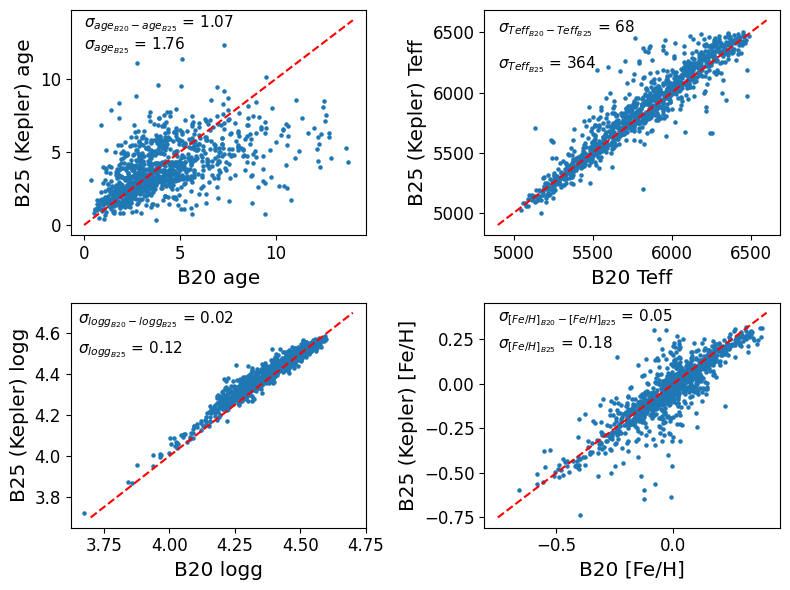

In [51]:
fig, axes = plt.subplots(2,2, figsize=(8,6))

#b20_b26_culled = pd.merge(b20_kepler_culled[['KIC','iso_age','iso_age_err1','iso_age_err2','iso_teff','iso_teff_err1','iso_teff_err2','iso_logg','iso_feh']], b26_kepler_culled[['KIC','Age','E_Age','e_Age','Teff','E_Teff','logg','feh']], on='KIC')
b20_b26_culled = pd.merge(b20_kepler_culled, b26_kepler_culled, on='KIC')
axes[0,0].scatter(b20_b26_culled.iso_age, b20_b26_culled.Age, s=5)
#axes[0,0].errorbar(b20_b26_culled.iso_age, b20_b26_culled.Age, xerr=[b20_b26_culled.iso_age_err1, np.abs(b20_b26_culled.iso_age_err2)], yerr=[b20_b26_culled.E_Age, np.abs(b20_b26_culled.e_Age)], fmt='o', c='k', alpha=0.5, linestyle='')
axes[0,0].plot(np.linspace(0, 14, 10), np.linspace(0, 14, 10), c='red', linestyle='--')
axes[0,0].set_xlabel('B20 age')
axes[0,0].set_ylabel('B25 (Kepler) age')
#axes[0,0].text(0.05, 0.95, f'N={len(b20_b26_culled)}', transform=axes[0,0].transAxes, fontsize=12, verticalalignment='top')
x_rms = np.round(np.std(np.sqrt(0.5*(b20_b26_culled.iso_age-b20_b26_culled.Age)**2)),2)
x_std = np.round(np.std(b20_b26_culled.Age),2)
axes[0,0].text(0, 13.5, r'$\sigma_{age_{B20}-age_{B25}}$ = ' + f'{x_rms}', fontsize=11, horizontalalignment='left')
axes[0,0].text(0, 12, r'$\sigma_{age_{B25}}$ = ' + f'{x_std}', fontsize=11, horizontalalignment='left')

axes[0,1].scatter(b20_b26_culled.iso_teff, b20_b26_culled.Teff, s=5)
axes[0,1].plot(np.linspace(4900, 6600, 10), np.linspace(4900, 6600, 10), c='red', linestyle='--')
axes[0,1].set_xlabel('B20 Teff')
axes[0,1].set_ylabel('B25 (Kepler) Teff')
x_rms = int(np.std(np.sqrt(0.5*(b20_b26_culled.iso_teff-b20_b26_culled.Teff)**2)))
x_std = int(np.std(b20_b26_culled.Teff))
axes[0,1].text(4900, 6500, r'$\sigma_{Teff_{B20}-Teff_{B25}}$ = ' + f'{x_rms}', fontsize=11, horizontalalignment='left')
axes[0,1].text(4900, 6200, r'$\sigma_{Teff_{B25}}$ = ' + f'{x_std}', fontsize=11, horizontalalignment='left')

axes[1,0].scatter(b20_b26_culled.iso_logg, b20_b26_culled.logg, s=5)
axes[1,0].plot(np.linspace(3.7, 4.7, 10), np.linspace(3.7, 4.7, 10), c='red', linestyle='--')
axes[1,0].set_xlabel('B20 logg')
axes[1,0].set_ylabel('B25 (Kepler) logg')
x_rms = np.round(np.std(np.sqrt(0.5*(b20_b26_culled.iso_logg-b20_b26_culled.logg)**2)),2)
x_std = np.round(np.std(b20_b26_culled.logg),2)
axes[1,0].text(3.65, 4.65, r'$\sigma_{logg_{B20}-logg_{B25}}$ = ' + f'{x_rms}', fontsize=11, horizontalalignment='left')
axes[1,0].text(3.65, 4.5, r'$\sigma_{logg_{B25}}$ = ' + f'{x_std}', fontsize=11, horizontalalignment='left')

axes[1,1].scatter(b20_b26_culled.iso_feh, b20_b26_culled.feh, s=5)
axes[1,1].plot(np.linspace(-.75,.4, 10), np.linspace(-.75,.4, 10), c='red', linestyle='--')
axes[1,1].set_xlabel('B20 [Fe/H]')
axes[1,1].set_ylabel('B25 (Kepler) [Fe/H]')
x_rms = np.round(np.std(np.sqrt(0.5*(b20_b26_culled.iso_feh-b20_b26_culled.feh)**2)),2)
x_std = np.round(np.std(b20_b26_culled.feh),2)
axes[1,1].text(-.75, .35, r'$\sigma_{[Fe/H]_{B20}-[Fe/H]_{B25}}$ = ' + f'{x_rms}', fontsize=11, horizontalalignment='left')
axes[1,1].text(-.75, .2, r'$\sigma_{[Fe/H]_{B25}}$ = ' + f'{x_std}', fontsize=11, horizontalalignment='left')

plt.tight_layout()
plt.savefig(path+'plots/berger2020_2025_comparison.pdf', dpi=300, format='pdf')
plt.show()


In [67]:
# cross match HU25 and B20 culled catalogs to see how many stars are in common, and how their parameters compare
hu25_b20_culled = pd.merge(kepler_stars_culled[['Kepler_ID','Teff','e_Teff','logg','e_logg','Lum','e_Lum','[Fe/H]','e_[Fe/H]','Rad','e_Rad','Mass','e_Mass','CDPP75','CDPP6']], b20_kepler_culled[['KIC','iso_teff','iso_logg','iso_lum','iso_age','iso_age_err1','iso_age_err2','iso_feh']], left_on='Kepler_ID', right_on='KIC')
print(len(hu25_b20_culled))

60591


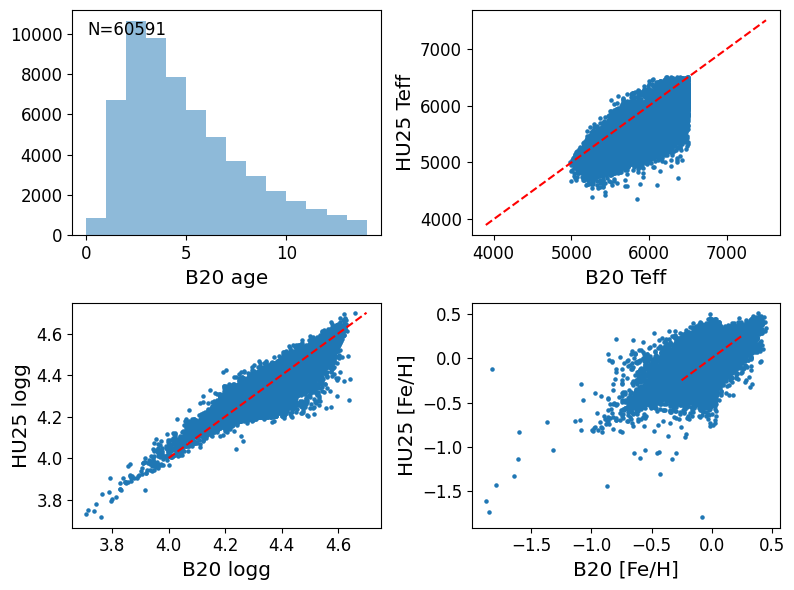

In [9]:
fig, axes = plt.subplots(2,2, figsize=(8,6))

#axes[0,0].scatter(hu25_b20_culled.iso_age, hu25_b20_culled.Age, s=5)
#axes[0,0].plot(np.linspace(0, 14, 10), np.linspace(0, 14, 10), c='red', linestyle='--')
axes[0,0].set_xlabel('B20 age')
#axes[0,0].set_ylabel('HU25 age')
axes[0,0].hist(hu25_b20_culled.iso_age, bins=np.linspace(0, 14, 15), alpha=0.5, label='B20 age')
axes[0,0].text(0.05, 0.95, f'N={len(hu25_b20_culled)}', transform=axes[0,0].transAxes, fontsize=12, verticalalignment='top')

axes[0,1].scatter(hu25_b20_culled.iso_teff, hu25_b20_culled.Teff, s=5)
axes[0,1].plot(np.linspace(3900, 7500, 10), np.linspace(3900, 7500, 10), c='red', linestyle='--')
axes[0,1].set_xlabel('B20 Teff')
axes[0,1].set_ylabel('HU25 Teff')

axes[1,0].scatter(hu25_b20_culled.iso_logg, hu25_b20_culled.logg, s=5)
axes[1,0].plot(np.linspace(4., 4.7, 10), np.linspace(4., 4.7, 10), c='red', linestyle='--')
axes[1,0].set_xlabel('B20 logg')
axes[1,0].set_ylabel('HU25 logg')

axes[1,1].scatter(hu25_b20_culled.iso_feh, hu25_b20_culled['[Fe/H]'], s=5)
axes[1,1].plot(np.linspace(-.25,.25, 10), np.linspace(-.25,.25, 10), c='red', linestyle='--')
axes[1,1].set_xlabel('B20 [Fe/H]')
axes[1,1].set_ylabel('HU25 [Fe/H]')

plt.tight_layout()
plt.show()


Check that host and non-hosts among B20 have the same or similar age distributions

76375 1813
K-S age:  0.07912223683652253 4.322809890827041e-10
A-D age:  23.433894982554058 0.001


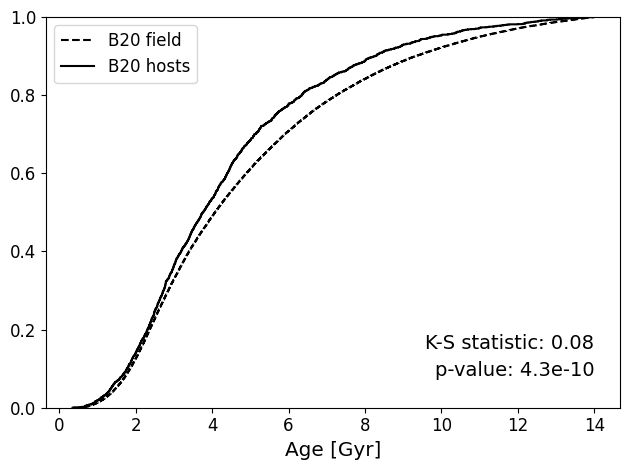

In [53]:
# source: https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=cumulative
kois = pd.read_csv(path+'data/cumulative_2021.03.04_20.04.43.csv')
kois = kois.loc[kois.koi_disposition != 'FALSE POSITIVE']

b20_field = b20_kepler_culled.loc[~b20_kepler_culled.KIC.isin(kois.kepid)]
b20_hosts = b20_kepler_culled.loc[b20_kepler_culled.KIC.isin(kois.kepid)]
print(len(b20_field), len(b20_hosts))

from scipy.stats import ks_2samp
from scipy.stats import anderson_ksamp

ks_stat, p_value = ks_2samp(b20_field['iso_age'], b20_hosts['iso_age'])
print("K-S age: ", ks_stat, p_value)

result = anderson_ksamp([b20_field['iso_age'], b20_hosts['iso_age']])
print("A-D age: ", result.statistic, result.significance_level)

plt.ecdf(b20_field['iso_age'], linestyle='--', c='k',label='B20 field')
plt.ecdf(b20_hosts['iso_age'], c='k', label='B20 hosts')
plt.text(14, 0.15, f"K-S statistic: {np.round(ks_stat, 2)}", fontsize=14, horizontalalignment='right')
plt.text(14, 0.08, f"p-value: {p_value:.1e}", fontsize=14, horizontalalignment='right')
plt.xlabel(r"Age [Gyr]")
plt.legend()
plt.tight_layout()
plt.savefig(path+'plots/berger2020_field_hosts_age_comparison.pdf', dpi=75, format='pdf')
plt.show()

Bootstrap version of the K-S plot

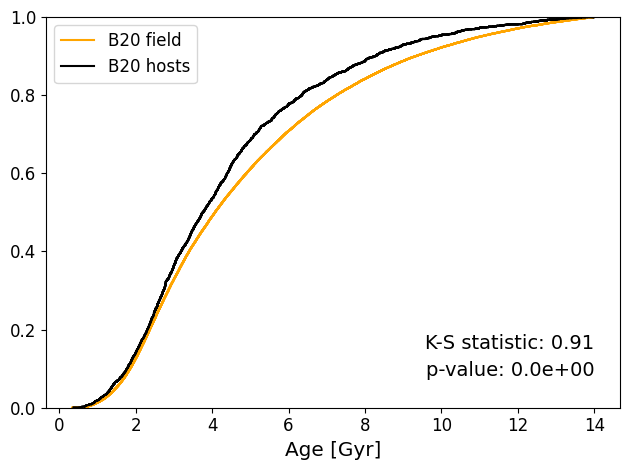

In [112]:
b20_field_age = draw_asymmetrically(b20_field, 'iso_age', 'iso_age_err1', 'iso_age_err2', 'age')
b20_hosts_age = draw_asymmetrically(b20_hosts, 'iso_age', 'iso_age_err1', 'iso_age_err2', 'age')

plt.ecdf(b20_field['iso_age'], c='orange',label='B20 field')
plt.ecdf(b20_hosts['iso_age'], c='k', label='B20 hosts')
    
for i in range(5):
    b20_field_age = draw_asymmetrically(b20_field, 'iso_age', 'iso_age_err1', 'iso_age_err2', 'age')
    b20_hosts_age = draw_asymmetrically(b20_hosts, 'iso_age', 'iso_age_err1', 'iso_age_err2', 'age')

    plt.ecdf(b20_field['iso_age'], c='orange')
    plt.ecdf(b20_hosts['iso_age'], c='k')

plt.text(14, 0.15, f"K-S statistic: {np.round(ks_stat, 2)}", fontsize=14, horizontalalignment='right')
plt.text(14, 0.08, f"p-value: {p_value:.1e}", fontsize=14, horizontalalignment='right')
plt.xlabel(r"Age [Gyr]")
plt.legend()
plt.tight_layout()
plt.show()


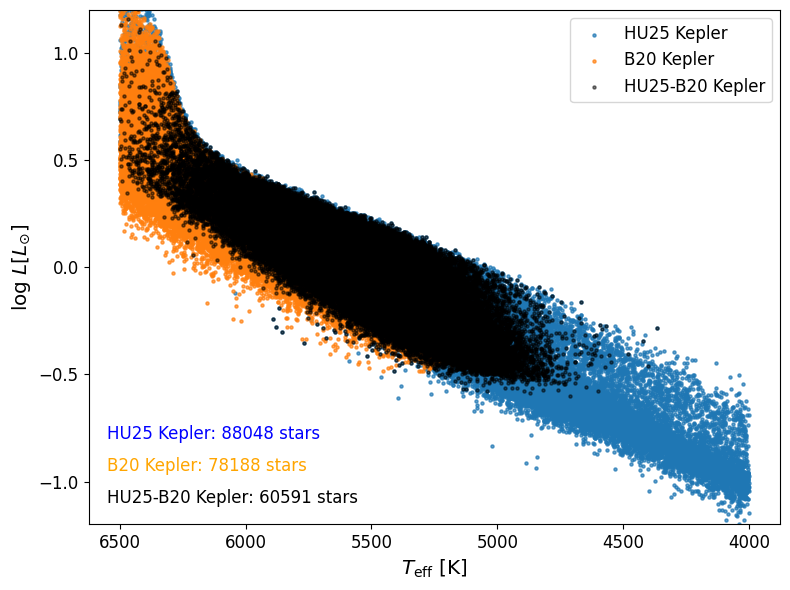

In [122]:
# figure and grid layout
fig = plt.figure(figsize=(8, 6))
#gs = GridSpec(2, 3, figure=fig, wspace=0.05, hspace=0.05, width_ratios=[8, 1, 0.25], height_ratios=[1, 8]) # two horizontal assets, but third vertical asset required for colorbar

# main scatter plot spans bottom-left
#ax_scatter = fig.add_subplot(gs[1, 0])
ax_scatter = fig.add_subplot()

ax_scatter.scatter(kepler_stars_culled['Teff'], np.log10(kepler_stars_culled['Lum']), s=5, alpha=0.7, label='HU25 Kepler')
ax_scatter.scatter(b20_kepler_culled['iso_teff'], b20_kepler_culled['iso_lum'], s=5, alpha=0.7, label='B20 Kepler')
ax_scatter.scatter(hu25_b20_culled['Teff'], np.log10(hu25_b20_culled['Lum']), c='k', s=5, alpha=0.5, label='HU25-B20 Kepler')
#ax_scatter.scatter(hu25_b20_culled['iso_teff'], hu25_b20_culled['iso_lum'], s=5, alpha=0.2, label='HU25-B20 Kepler (DR2)')

ax_scatter.set_xlabel(r"$T_{\rm eff}$ [K]")
#ax_scatter.set_ylabel(r'$M_{K_{s}}$')
ax_scatter.set_ylabel(r'log $L [L_{\odot}]$')
#plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
#ax_scatter.set_xlim([7600, 3900])
#ax_scatter.set_ylim([4.7, 3.6])
ax_scatter.set_ylim([-1.2, 1.2])
#plt.legend(fontsize='medium')
#plt.legend(loc='upper left', bbox_to_anchor=(0.02, 1.0), fontsize='medium')

plt.text(6550, -0.8, 'HU25 Kepler: ' + f'{len(kepler_stars_culled)}' + ' stars', fontsize=12, color='blue')
plt.text(6550, -0.95, 'B20 Kepler: ' + f'{len(b20_kepler_culled)}' + ' stars', fontsize=12, color='orange')
plt.text(6550, -1.1, 'HU25-B20 Kepler: ' + f'{len(hu25_b20_culled)}' + ' stars', fontsize=12, color='k')

plt.tight_layout()
plt.legend(loc='upper right')
plt.savefig(path+'plots/hr_hu25_b20.png', bbox_inches='tight')
plt.show()

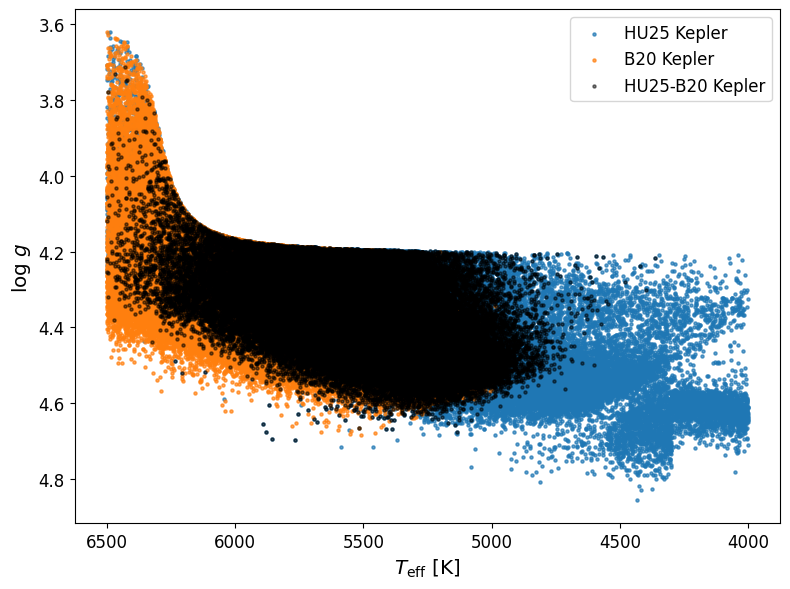

In [120]:
# figure and grid layout
fig = plt.figure(figsize=(8, 6))
#gs = GridSpec(2, 3, figure=fig, wspace=0.05, hspace=0.05, width_ratios=[8, 1, 0.25], height_ratios=[1, 8]) # two horizontal assets, but third vertical asset required for colorbar

# main scatter plot spans bottom-left
ax_scatter = fig.add_subplot()

ax_scatter.scatter(kepler_stars_culled['Teff'], kepler_stars_culled['logg'], s=5, alpha=0.7, label='HU25 Kepler')
ax_scatter.scatter(b20_kepler_culled['iso_teff'], b20_kepler_culled['iso_logg'], s=5, alpha=0.7, label='B20 Kepler')
ax_scatter.scatter(hu25_b20_culled['Teff'], hu25_b20_culled['logg'], s=5, alpha=0.5, c='k', label='HU25-B20 Kepler')
#ax_scatter.scatter(hu25_b20_culled['iso_teff'], hu25_b20_culled['iso_logg'], s=5, alpha=0.2, label='HU25-B20 Kepler (DR2)')

ax_scatter.set_xlabel(r"$T_{\rm eff}$ [K]")
#ax_scatter.set_ylabel(r'$M_{K_{s}}$')
#ax_scatter.set_ylabel(r'log $L [L_{\odot}]$')
ax_scatter.set_ylabel(r'log $g$')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
#ax_scatter.set_xlim([7600, 3900])
#ax_scatter.set_ylim([4.7, 3.6])
#ax_scatter.set_ylim([5.1, 1.1])

plt.tight_layout()
plt.legend(loc='upper right')
plt.savefig(path+'plots/kiel_hu25_b20.png', bbox_inches='tight')
plt.show()

In [56]:
from scipy.stats import ks_2samp
from scipy.stats import anderson_ksamp

ks_stat, p_value = ks_2samp(hu25_b20_culled['Teff'], hu25_b20_culled['iso_teff'])
print("K-S Teff: ", ks_stat, p_value)

ks_stat, p_value = ks_2samp(hu25_b20_culled['Lum'], hu25_b20_culled['iso_lum'])
print("K-S logg: ", ks_stat, p_value)

result = anderson_ksamp([hu25_b20_culled['Teff'], hu25_b20_culled['iso_teff']])
print("A-D Teff: ", result.statistic, result.significance_level)

result = anderson_ksamp([hu25_b20_culled['logg'], hu25_b20_culled['iso_logg']])
print("A-D logg: ", result.statistic, result.significance_level)

K-S Teff:  0.3111188130250367 0.0
K-S logg:  0.9132049314254592 0.0
A-D Teff:  10649.530380816053 0.001
A-D logg:  1066.7706424144515 0.001


K2

In [68]:
# cross match HU25 and B26 culled catalogs to see how many stars are in common, and how their parameters compare
hu25_b26_culled = pd.merge(k2_stars_culled[['EPIC_ID','GaiaDR3','Campaign','Teff','e_Teff','logg','e_logg','Lum','e_Lum','[Fe/H]','e_[Fe/H]','Rad','e_Rad','Mass','e_Mass','CDPP6','CDPP8']], b26_k2_culled[['EPIC','Teff','logg','L_star','Age','E_Age','e_Age','feh']], left_on='EPIC_ID', right_on='EPIC')
print(len(hu25_b26_culled))

273


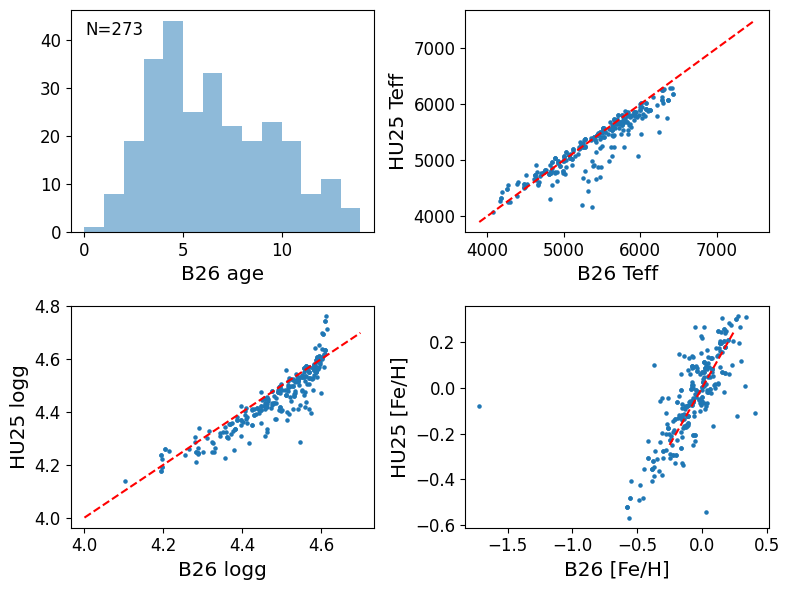

In [58]:
fig, axes = plt.subplots(2,2, figsize=(8,6))

axes[0,0].set_xlabel('B26 age')
axes[0,0].hist(hu25_b26_culled.Age, bins=np.linspace(0, 14, 15), alpha=0.5, label='B26 age')
axes[0,0].text(0.05, 0.95, f'N={len(hu25_b26_culled)}', transform=axes[0,0].transAxes, fontsize=12, verticalalignment='top')

axes[0,1].scatter(hu25_b26_culled.Teff_y, hu25_b26_culled.Teff_x, s=5)
axes[0,1].plot(np.linspace(3900, 7500, 10), np.linspace(3900, 7500, 10), c='red', linestyle='--')
axes[0,1].set_xlabel('B26 Teff')
axes[0,1].set_ylabel('HU25 Teff')

axes[1,0].scatter(hu25_b26_culled.logg_y, hu25_b26_culled.logg_x, s=5)
axes[1,0].plot(np.linspace(4., 4.7, 10), np.linspace(4., 4.7, 10), c='red', linestyle='--')
axes[1,0].set_xlabel('B26 logg')
axes[1,0].set_ylabel('HU25 logg')

axes[1,1].scatter(hu25_b26_culled.feh, hu25_b26_culled['[Fe/H]'], s=5)
axes[1,1].plot(np.linspace(-.25,.25, 10), np.linspace(-.25,.25, 10), c='red', linestyle='--')
axes[1,1].set_xlabel('B26 [Fe/H]')
axes[1,1].set_ylabel('HU25 [Fe/H]')

plt.tight_layout()
plt.show()


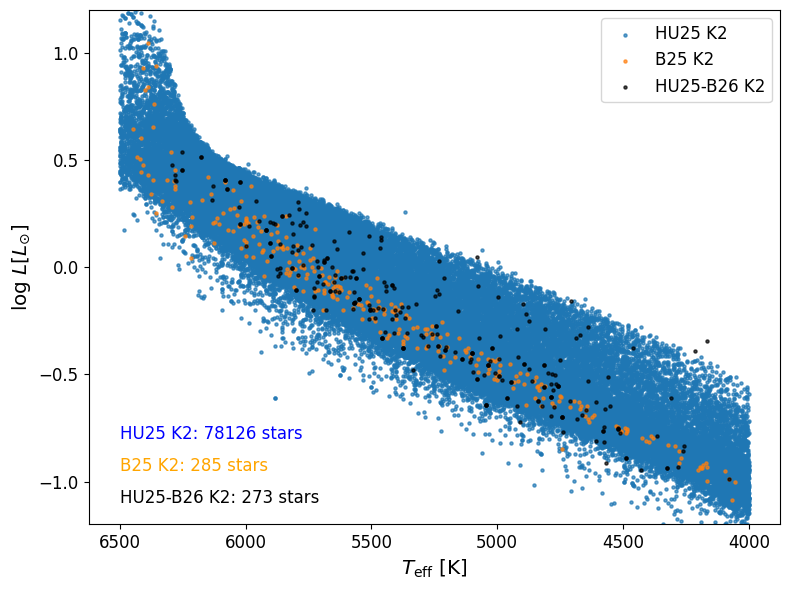

In [118]:
from matplotlib.gridspec import GridSpec

# figure and grid layout
fig = plt.figure(figsize=(8, 6))
#gs = GridSpec(2, 3, figure=fig, wspace=0.05, hspace=0.05, width_ratios=[8, 1, 0.25], height_ratios=[1, 8]) # two horizontal assets, but third vertical asset required for colorbar

# main scatter plot spans bottom-left
ax_scatter = fig.add_subplot()

ax_scatter.scatter(k2_stars_culled['Teff'], np.log10(k2_stars_culled['Lum']), s=5, alpha=0.7, label='HU25 K2')
ax_scatter.scatter(b26_k2_culled['Teff'], np.log10(b26_k2_culled['L_star']), s=5, alpha=0.7, label='B25 K2')
ax_scatter.scatter(hu25_b26_culled['Teff_x'], np.log10(hu25_b26_culled['L_star']), s=5, alpha=0.7, c='k', label='HU25-B26 K2')
# ax_scatter.scatter(kepler_stars['Teff'], kepler_stars['absK'], s=5, alpha=0.7, label='HU25 Kepler')
# ax_scatter.scatter(hu25_b20_kepler['Teff'], hu25_b20_kepler['absK'], s=5, alpha=0.7, label='B20 Kepler age cuts')

ax_scatter.set_xlabel(r"$T_{\rm eff}$ [K]")
#ax_scatter.set_ylabel(r'$M_{K_{s}}$')
ax_scatter.set_ylabel(r'log $L [L_{\odot}]$')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
#ax_scatter.set_xlim([7600, 3900])
#ax_scatter.set_ylim([4.7, 3.6])
ax_scatter.set_ylim([-1.2, 1.2])
#plt.legend(fontsize='medium')
#plt.legend(loc='upper left', bbox_to_anchor=(0.02, 1.0), fontsize='medium')

plt.text(6500, -0.8, 'HU25 K2: ' + f'{len(k2_stars_culled)}' + ' stars', fontsize=12, color='blue')
plt.text(6500, -0.95, 'B25 K2: ' + f'{len(b26_k2_culled)}' + ' stars', fontsize=12, color='orange')
plt.text(6500, -1.1, 'HU25-B26 K2: ' + f'{len(hu25_b26_culled)}' + ' stars', fontsize=12, color='k')

plt.tight_layout()
plt.legend(loc='upper right')
plt.savefig(path+'plots/k2/hr_hu25_b25.png', bbox_inches='tight')
plt.show()

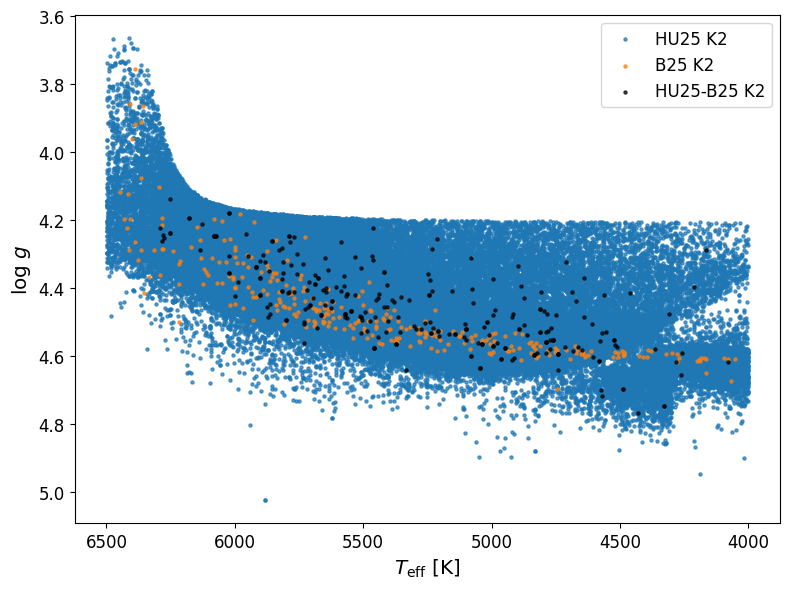

In [119]:
# figure and grid layout
fig = plt.figure(figsize=(8, 6))
#gs = GridSpec(2, 3, figure=fig, wspace=0.05, hspace=0.05, width_ratios=[8, 1, 0.25], height_ratios=[1, 8]) # two horizontal assets, but third vertical asset required for colorbar

# main scatter plot spans bottom-left
ax_scatter = fig.add_subplot()

ax_scatter.scatter(k2_stars_culled['Teff'], k2_stars_culled['logg'], s=5, alpha=0.7, label='HU25 K2')
ax_scatter.scatter(b26_k2_culled['Teff'], b26_k2_culled['logg'], s=5, alpha=0.7, label='B25 K2')
ax_scatter.scatter(hu25_b26_culled['Teff_x'], hu25_b26_culled['logg_x'], s=5, c='k', alpha=0.7, label='HU25-B25 K2')

ax_scatter.set_xlabel(r"$T_{\rm eff}$ [K]")
#ax_scatter.set_ylabel(r'$M_{K_{s}}$')
#ax_scatter.set_ylabel(r'log $L [L_{\odot}]$')
ax_scatter.set_ylabel(r'log $g$')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
#ax_scatter.set_xlim([7600, 3900])
#ax_scatter.set_ylim([4.7, 3.6])
#ax_scatter.set_ylim([5.1, 1.1])

plt.tight_layout()
plt.legend(loc='upper right')
plt.savefig(path+'plots/k2/kiel_hu25_b25.png', bbox_inches='tight')
plt.show()

### Cull by astrometric solution

In [76]:
# remove Kepler stars without full astrometric solution
bedell = Table.read(path+'data/kepler_dr3_good.fits')
bedell_df = bedell.to_pandas()
hu25_b20_astrometric = pd.merge(hu25_b20_culled, bedell_df[['kepid', 'source_id', 'ra', 'dec', 'parallax', 'parallax_error', 'pmra', 'pmra_error', 'pmdec', 'pmdec_error', 'radial_velocity', 'radial_velocity_error']], left_on='Kepler_ID', right_on='kepid', how='left')
hu25_b20_astrometric = hu25_b20_astrometric.dropna(subset=['parallax', 'parallax_error', 'ra', 'dec', 'pmra', 'pmra_error', 'pmdec', 'pmdec_error', 'radial_velocity', 'radial_velocity_error'])
print("astrometric solution cut: ", len(hu25_b20_astrometric))

hu25_b20_astrometric['height'] = gala_galactic_heights_k2(Table.from_pandas(hu25_b20_astrometric))

astrometric solution cut:  24883


100%|██████████| 24883/24883 [02:34<00:00, 161.18it/s]


In [77]:
# same for K2 stars

# without a K2 equivalent of the Bedell Gaia-Kepler crossmatch, we need to first enrich with astrometric info from Gaia DR3
from astroquery.gaia import Gaia

# list of Gaia DR3 source IDs
k2_source_ids = list(hu25_b26_culled['GaiaDR3'])

# convert to ADQL list
k2_source_list = ",".join(str(s) for s in k2_source_ids)

query = f"""
SELECT source_id,
       ra, dec,
       parallax,
       pmra, pmdec,
       radial_velocity,
	   ra_error, dec_error, parallax_error, pmra_error, pmdec_error, radial_velocity_error
FROM gaiadr3.gaia_source
WHERE source_id IN ({k2_source_list})
"""

job = Gaia.launch_job_async(query)
results = job.get_results()

k2_astrometry = results.to_pandas()
k2_astrometry

INFO: Query finished. [astroquery.utils.tap.core]


,SOURCE_ID,ra,dec,parallax,pmra,pmdec,radial_velocity,ra_error,dec_error,parallax_error,pmra_error,pmdec_error,radial_velocity_error
0,61624573016925824,52.888851,22.434817,4.615705,-7.942969,-10.844134,0.973049,0.013907,0.010376,0.014570,0.019928,0.014409,1.377523
1,655863775507590400,125.223916,16.090791,1.840995,9.805472,-34.567896,-69.233032,0.016108,0.010309,0.018952,0.017103,0.012747,2.652549
2,2533837126169762688,19.626881,-0.056395,4.297628,23.439312,25.664707,-9.495068,0.018943,0.017766,0.022622,0.032041,0.022823,1.007185
3,2599322178998513664,337.044246,-14.599336,4.264093,-3.042030,11.698896,-8.641218,0.017266,0.013766,0.020042,0.020922,0.015885,1.052269
4,3810609819552494976,170.103103,1.285865,3.914518,4.410950,-19.358890,56.000984,0.016148,0.014028,0.020260,0.019678,0.016874,5.309920
...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,3618083684261605248,205.389435,-9.390862,2.262441,-16.743414,-5.846610,-19.195152,0.016359,0.010962,0.019489,0.018420,0.013231,1.456750
210,3798552815560689792,171.515188,1.230620,4.021887,3.366978,-26.804533,-38.968273,0.012062,0.012565,0.015990,0.016238,0.013829,1.052241
211,3807078737959680000,157.927267,0.353841,2.835186,-3.278158,6.263191,13.497627,0.016725,0.018599,0.020696,0.021398,0.020578,4.223837
212,3869833394179651584,159.131493,9.241580,5.293736,5.870675,-12.032962,0.800108,0.018102,0.012572,0.017420,0.021375,0.015222,0.402984


In [78]:
hu25_b26_culled_astrometry = pd.merge(hu25_b26_culled, k2_astrometry, left_on='GaiaDR3', right_on='SOURCE_ID')

In [79]:
# calculate Zmax for K2 sample
hu25_b26_culled_astrometry['height'] = gala_galactic_heights_k2(Table.from_pandas(hu25_b26_culled_astrometry))

100%|██████████| 273/273 [00:01<00:00, 174.11it/s]


### Combine to make final sample

In [81]:
hu25_b20_astrometric.columns

Index(['Kepler_ID', 'Teff', 'e_Teff', 'logg', 'e_logg', 'Lum', 'e_Lum',
       '[Fe/H]', 'e_[Fe/H]', 'Rad', 'e_Rad', 'Mass', 'e_Mass', 'CDPP75',
       'CDPP6', 'KIC', 'iso_teff', 'iso_logg', 'iso_lum', 'iso_age',
       'iso_age_err1', 'iso_age_err2', 'iso_feh', 'kepid', 'source_id', 'ra',
       'dec', 'parallax', 'parallax_error', 'pmra', 'pmra_error', 'pmdec',
       'pmdec_error', 'radial_velocity', 'radial_velocity_error', 'height'],
      dtype='object')

In [80]:
hu25_b26_culled_astrometry.columns

Index(['EPIC_ID', 'GaiaDR3', 'Campaign', 'Teff_x', 'e_Teff', 'logg_x',
       'e_logg', 'Lum', 'e_Lum', '[Fe/H]', 'e_[Fe/H]', 'Rad', 'e_Rad', 'Mass',
       'e_Mass', 'CDPP6', 'CDPP8', 'EPIC', 'Teff_y', 'logg_y', 'L_star', 'Age',
       'E_Age', 'e_Age', 'feh', 'SOURCE_ID', 'ra', 'dec', 'parallax', 'pmra',
       'pmdec', 'radial_velocity', 'ra_error', 'dec_error', 'parallax_error',
       'pmra_error', 'pmdec_error', 'radial_velocity_error', 'height'],
      dtype='object')

In [82]:
hu25_b26_culled_astrometry.rename(columns={'Teff_x': 'Teff', 'logg_x': 'logg'}, inplace=True)

In [157]:
hu25_b20_kepler_b25_k2 = pd.concat([hu25_b20_astrometric, hu25_b26_culled_astrometry]).reset_index()
hu25_b20_kepler_b25_k2 = hu25_b20_kepler_b25_k2.drop(columns=['index', 'Teff_y', 'logg_y'])

# combine Kepler and K2 age columns into the same name
hu25_b20_kepler_b25_k2['age'] = hu25_b20_kepler_b25_k2['iso_age'].combine_first(hu25_b20_kepler_b25_k2['Age'])
hu25_b20_kepler_b25_k2['age_err1'] = hu25_b20_kepler_b25_k2['iso_age_err1'].combine_first(hu25_b20_kepler_b25_k2['E_Age'])
hu25_b20_kepler_b25_k2['age_err2'] = hu25_b20_kepler_b25_k2['iso_age_err2'].combine_first(hu25_b20_kepler_b25_k2['e_Age'])

# combine Gaia DR3 source id columns into the same name
hu25_b20_kepler_b25_k2['source_id_dr3'] = hu25_b20_kepler_b25_k2['source_id'].combine_first(hu25_b20_kepler_b25_k2['GaiaDR3'])

hu25_b20_kepler_b25_k2.to_csv(path+'data/joint/hu25_b20_kepler_b25_k2.csv', index=False)

In [155]:
hu25_b20_kepler_b25_k2.columns

Index(['Kepler_ID', 'Teff', 'e_Teff', 'logg', 'e_logg', 'Lum', 'e_Lum',
       '[Fe/H]', 'e_[Fe/H]', 'Rad', 'e_Rad', 'Mass', 'e_Mass', 'CDPP75',
       'CDPP6', 'KIC', 'iso_teff', 'iso_logg', 'iso_lum', 'iso_age',
       'iso_age_err1', 'iso_age_err2', 'iso_feh', 'kepid', 'source_id', 'ra',
       'dec', 'parallax', 'parallax_error', 'pmra', 'pmra_error', 'pmdec',
       'pmdec_error', 'radial_velocity', 'radial_velocity_error', 'height',
       'EPIC_ID', 'GaiaDR3', 'Campaign', 'CDPP8', 'EPIC', 'L_star', 'Age',
       'E_Age', 'e_Age', 'feh', 'SOURCE_ID', 'ra_error', 'dec_error', 'age',
       'age_err1', 'age_err2'],
      dtype='object')

### Plot age vs Zmax

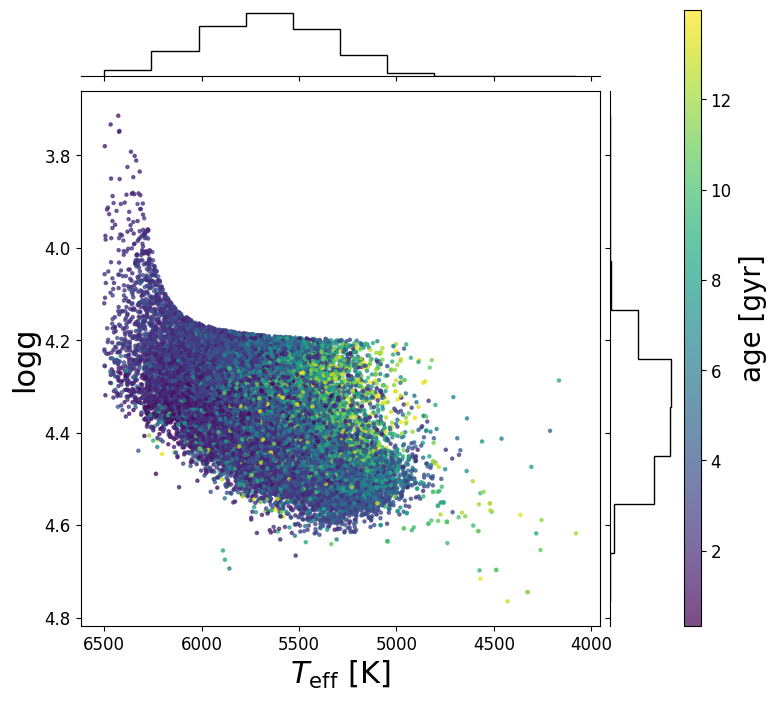

median Teff:  5671.0
median logg:  4.358
min and max Teff:  4079 6499
min and max logg:  3.714 4.765


In [142]:
from matplotlib.gridspec import GridSpec

# figure and grid layout
fig = plt.figure(figsize=(8, 8))
gs = GridSpec(2, 3, figure=fig, wspace=0.05, hspace=0.05, width_ratios=[8, 1, 0.25], height_ratios=[1, 8]) # two horizontal assets, but third vertical asset required for colorbar

# main scatter plot spans bottom-left
ax_scatter = fig.add_subplot(gs[1, 0])

# top histogram spans top-left
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
pos = ax_histx.get_position()
ax_histx.set_position([pos.x0, pos.y0 + 0.00, pos.width, pos.height])
ax_histx.set_yticks([])

# right histogram spans bottom-right
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)
ax_histy.set_xticks([])

im = ax_scatter.scatter(hu25_b20_kepler_b25_k2['Teff'], hu25_b20_kepler_b25_k2['logg'], s=5, alpha=0.7, c=hu25_b20_kepler_b25_k2['age'], marker='o')

# histograms
ax_histx.hist(hu25_b20_kepler_b25_k2['Teff'], bins=10, histtype='step', color="k", linewidth=1)
ax_histy.hist(hu25_b20_kepler_b25_k2['logg'], bins=10, orientation='horizontal', histtype='step', color="k", linewidth=1)
ax_histx.invert_xaxis()
ax_histy.invert_yaxis()
#ax_histy.invert_xaxis()

# tidy up shared axes
plt.setp(ax_histx.get_xticklabels(), visible=False)
plt.setp(ax_histy.get_yticklabels(), visible=False)
#fig.subplots_adjust(hspace=1.25)   # increase vertical spacing

# remove spines from histograms
ax_histx.spines['right'].set_visible(False)
ax_histx.spines['top'].set_visible(False)
ax_histx.spines['left'].set_visible(False)

ax_histy.spines['right'].set_visible(False)
ax_histy.spines['top'].set_visible(False)
ax_histy.spines['bottom'].set_visible(False)

# add colorbar as final asset
ax_cbar = fig.add_subplot(gs[:, 2])

ax_scatter.set_xlabel(r"$T_{\rm eff}$ [K]", fontsize=22)
ax_scatter.set_ylabel('logg', fontsize=22)
#plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
#ax_scatter.set_xlim([7600, 3900])
#ax_scatter.set_ylim([4.7, 3.6])
#plt.legend(fontsize='medium')
#plt.legend(loc='upper left', bbox_to_anchor=(0.02, 1.0), fontsize='medium')
#cbar = plt.colorbar(im, cmap='viridis', label='age [Gyr]')
cbar = fig.colorbar(im, cax=ax_cbar)
cbar.set_label('age [gyr]', labelpad=5, fontsize=20)
cbar.ax.yaxis.set_label_position("right")
plt.tight_layout()
plt.savefig(path+'plots/kiel_hu25_b20_kepler_b25_k2.png', bbox_inches='tight', format='png')
plt.show()

print("median Teff: ", np.median(hu25_b20_kepler_b25_k2['Teff']))
print("median logg: ", np.median(hu25_b20_kepler_b25_k2['logg']))
print("min and max Teff: ", np.min(hu25_b20_kepler_b25_k2['Teff']), np.max(hu25_b20_kepler_b25_k2['Teff']))
print("min and max logg: ", np.min(hu25_b20_kepler_b25_k2['logg']), np.max(hu25_b20_kepler_b25_k2['logg']))

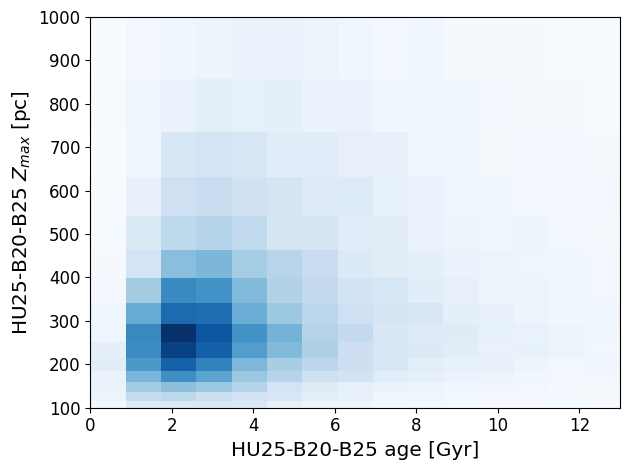

In [141]:
bins2d = [np.linspace(0, 13, 16), np.logspace(2, 3, 16)]

label='HU25'
ages = hu25_b20_kepler_b25_k2['age']
heights = hu25_b20_kepler_b25_k2['height']*1000
norm = 10
#print(ages)
#print(heights)
hist, xedges, yedges = np.histogram2d(ages, heights, bins=bins2d)
hist = hist.T

normalized = False
if normalized==True:
	with np.errstate(divide='ignore', invalid='ignore'):  # suppress division by zero warnings
		hist *= norm / hist.sum(axis=0, keepdims=True)
		#hist *= norm / hist.sum(axis=1, keepdims=True)
if label=='TRI':
	ax = plt.pcolormesh(xedges, yedges, hist, cmap='Blues')
	plt.xlabel('TRILEGAL age [Gyr]')
	plt.ylabel(r'TRILEGAL $Z_{max}$ [pc]')
elif label=='HU25':
	ax = plt.pcolormesh(xedges, yedges, hist, cmap='Blues')
	plt.xlabel('HU25-B20-B25 age [Gyr]')
	plt.ylabel(r'HU25-B20-B25 $Z_{max}$ [pc]')
#plt.legend(bbox_to_anchor=(1., 1.05))
#plt.yscale('log')
plt.tight_layout()
plt.savefig(path+'plots/age_vs_height_hu25_b20_kepler_b25_k2.png')
plt.show()

### Scratch work

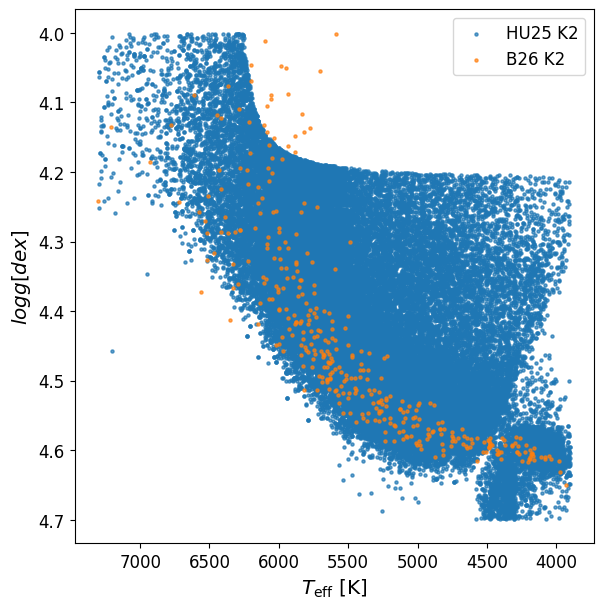

In [17]:
from matplotlib.gridspec import GridSpec

# figure and grid layout
fig = plt.figure(figsize=(8, 8))
gs = GridSpec(2, 3, figure=fig, wspace=0.05, hspace=0.05, width_ratios=[8, 1, 0.25], height_ratios=[1, 8]) # two horizontal assets, but third vertical asset required for colorbar

# main scatter plot spans bottom-left
ax_scatter = fig.add_subplot(gs[1, 0])

ax_scatter.scatter(k2_stars_culled['Teff'], k2_stars_culled['logg'], s=5, alpha=0.7, label='HU25 K2')
ax_scatter.scatter(b26_k2_culled['Teff'], b26_k2_culled['logg'], s=5, alpha=0.7, label='B26 K2')

ax_scatter.set_xlabel(r"$T_{\rm eff}$ [K]")
#ax_scatter.set_ylabel(r'$M_{K_{s}}$')
#ax_scatter.set_ylabel(r'($L [L_{\odot}]$)')
ax_scatter.set_ylabel(r'$log g [dex]$')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
#ax_scatter.set_xlim([7600, 3900])
#ax_scatter.set_ylim([4.7, 3.6])
#ax_scatter.set_ylim([5.1, 1.1])
#plt.legend(fontsize='medium')
#plt.legend(loc='upper left', bbox_to_anchor=(0.02, 1.0), fontsize='medium')
plt.tight_layout()
plt.legend()
#plt.savefig(path+'plots/k2/kiel_hu25_b26.png')
plt.show()

HR diagram of K2 HU25 (no age, DR3, includes non-hosts), K2 B25 (age, DR3, hosts only)

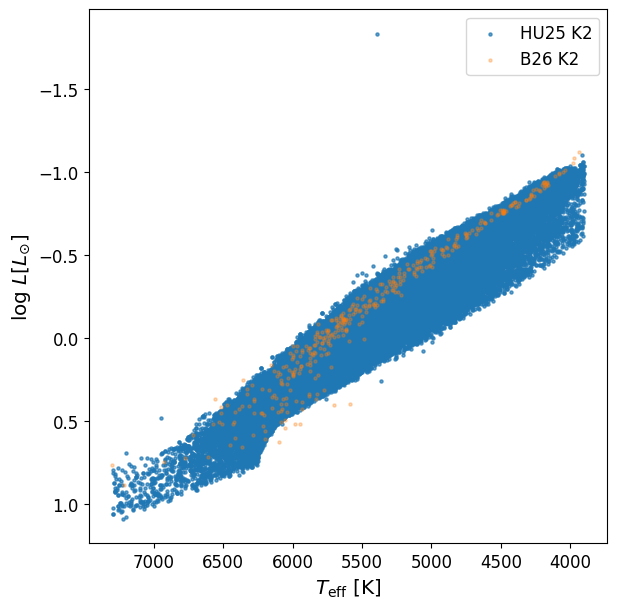

In [22]:
# figure and grid layout
fig = plt.figure(figsize=(8, 8))
gs = GridSpec(2, 3, figure=fig, wspace=0.05, hspace=0.05, width_ratios=[8, 1, 0.25], height_ratios=[1, 8]) # two horizontal assets, but third vertical asset required for colorbar

# main scatter plot spans bottom-left
ax_scatter = fig.add_subplot(gs[1, 0])

ax_scatter.scatter(k2_stars_culled['Teff'], np.log10(k2_stars_culled['Lum']), s=5, alpha=0.7, label='HU25 K2')
ax_scatter.scatter(b26_k2_culled['Teff'], np.log10(b26_k2_culled['L_star']), s=5, alpha=0.3, label='B26 K2')
#ax_scatter.scatter(hu25_b20_culled['Teff'], np.log10(hu25_b20_culled['Lum']), s=5, alpha=0.2, label='HU25-B20 Kepler (DR3)')
#ax_scatter.scatter(hu25_b20_culled['iso_teff'], hu25_b20_culled['iso_lum'], s=5, alpha=0.2, label='HU25-B20 Kepler (DR2)')

ax_scatter.set_xlabel(r"$T_{\rm eff}$ [K]")
#ax_scatter.set_ylabel(r'$M_{K_{s}}$')
ax_scatter.set_ylabel(r'log $L [L_{\odot}]$')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
#ax_scatter.set_xlim([7600, 3900])
#ax_scatter.set_ylim([4.7, 3.6])
#ax_scatter.set_ylim([5.1, 1.1])
#plt.legend(fontsize='medium')
#plt.legend(loc='upper left', bbox_to_anchor=(0.02, 1.0), fontsize='medium')
plt.tight_layout()
plt.legend()
#plt.savefig(path+'plots/hr_hu25_b20.png')
plt.show()

TRILEGAL

In [88]:
from astropy.coordinates import SkyCoord, Galactic

def convert_ra_dec_to_b(ra, dec):
	# Create a SkyCoord object in the ICRS (equatorial) frame
	# ICRS is the standard J2000 equatorial system assumed by default
	c_icrs = SkyCoord(ra=ra * u.degree, dec=dec * u.degree, frame='icrs')

	# Transform the coordinates to the Galactic frame
	c_galactic = c_icrs.transform_to(Galactic())
	# or use the shorthand attribute access:
	# c_galactic = c_icrs.galactic

	# The Galactic latitude 'b' is the angle from the Galactic midplane (b=0)
	b = c_galactic.b * u.degree
	
	return np.abs(b.value)

def degrees_to_radians(deg):
    return deg*np.pi/180

def dist_k2_to_height(d, b):
    """
    K2 fields have variable inclinations, so we need a second parameter, b, to do trigonometry.

    Inputs:
    - d: distance, in pc
    - b: inclination from Galactic midplane, in deg

    Output:
    - h: height off the Galactic midplane, in pc
    """

    incl = degrees_to_radians(b)
    h = d * np.sin(incl)

    return h

bs = []
for i in range(19):
    bs.append(convert_ra_dec_to_b(ras[i], decs[i]))

# K2 campaign pointings, from https://archive.stsci.edu/missions-and-data/k2/campaign-fields
ras = [173.939610, 246.1264, 336.66534641439, 59.0759116, 130.1576478, 204.8650344, 287.82850661, 16.3379975, 270.3544823, 186.7794430,
	   260.3880064, 351.6588124, 72.7971166, 160.6824762, 233.6175730, 133.7099689, 202.5496152, 
	   130.1610170, 347.2590265]
decs = [1.4172989, -22.4473, -11.096663792177, 18.6605794, 16.8296140, -11.2953585, -23.36001815, 5.2623459, -21.7798098, -4.0271572,
		-23.9759578, -5.1023328, 20.7870759, 6.8509316, -20.0792397, 18.5253931, -7.7210759, 
		16.8278629, -4.2027029]
campaigns = np.arange(19)+1
highs = [1, 3, 6, 8, 10, 12, 14, 17, 19]
lows = [2, 4, 5, 7, 9, 11, 13, 15, 16, 18]

k2_pointings = dict({'campaign': campaigns, 'ra': ras, 'dec': decs, 'b': bs})
print(k2_pointings)

{'campaign': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]), 'ra': [173.93961, 246.1264, 336.66534641439, 59.0759116, 130.1576478, 204.8650344, 287.82850661, 16.3379975, 270.3544823, 186.779443, 260.3880064, 351.6588124, 72.7971166, 160.6824762, 233.617573, 133.7099689, 202.5496152, 130.161017, 347.2590265], 'dec': [1.4172989, -22.4473, -11.096663792177, 18.6605794, 16.829614, -11.2953585, -23.36001815, 5.2623459, -21.7798098, -4.0271572, -23.9759578, -5.1023328, 20.7870759, 6.8509316, -20.0792397, 18.5253931, -7.7210759, 16.8278629, -4.2027029], 'b': [58.531292937220314, 18.532959446605993, 52.42647045809778, 25.947332351078384, 31.51387163024061, 49.84903553228032, 14.570462204991587, 57.43518020338808, 0.5592168377172165, 58.29587273157315, 7.211487713852137, 60.11396589334712, 14.77267573551696, 53.350902824912026, 28.464777359996905, 35.2829262192038, 53.90825186787161, 31.51620958465847, 56.49896205637861]}


In [92]:
import os
import re

stem = 'data/k2/trilegal/campaign' 
filenames = os.listdir(path+'data/k2/trilegal/')
tri_k2 = pd.DataFrame()
for i in range(len(filenames)):
	
	# there's a test file in this directory. skip it.
	if 'test' in filenames[i]:
		continue

	#temp_k2 = pd.read_csv(path+stem+f'{i+1}.dat.txt', sep='\s+')
	temp_k2 = pd.read_csv(path+'data/k2/trilegal/'+filenames[i], sep='\s+')
	temp_k2.dropna(subset=['logAge','m2/m1'], inplace=True)

	# remove end lines from TRILEGAL, if applicable
	try:
		temp_k2 = temp_k2[~temp_k2['logAge'].str.contains('normally', na=False)]
	except:
		pass

	# based on campaign, grab b of the pointing
	#temp_campaign = int(i)
	temp_campaign = int(re.search('campaign(.+?).dat', filenames[i]).group(1))
	temp_b = k2_pointings['b'][temp_campaign-1]
	#temp_b = k2_pointings[k2_pointings['campaign']==temp_campaign]['b']

	# add height column, introducing a spread of 0.05 dex based on TRILEGAL distance modulus bin size
	temp_k2['distance'] = simulate_helpers.distance_modulus_to_distance(temp_k2['m-M0'], perturb=True)
	temp_k2['height'] = dist_k2_to_height(temp_k2['distance'], temp_b)

	# add column for campaign and for whether it's high or low Galactic latitude
	temp_k2['campaign'] = temp_campaign

	tri_k2 = pd.concat([tri_k2, temp_k2])

print("initial TRI: ", len(tri_k2))

# remove binaries
tri_k2 = tri_k2[tri_k2['m2/m1']==0]
print("cut binaries: ", len(tri_k2))

# unlog Teff. keep FGK dwarfs only
tri_k2['Teff'] = 10**tri_k2['logTe'].astype(float)
#tri_k2 = tri_k2.loc[(tri_k2['Teff'] <= 6500) & (tri_k2['Teff'] >= 5300)] # keep only F and G dwarfs, pre-Kraft break
tri_k2 = tri_k2.loc[(tri_k2['Teff'] <= np.max(hu25_b26_culled['Teff_x'])) & (tri_k2['Teff'] >= np.min(hu25_b26_culled['Teff_x']))]
print("Teff cut: ", len(tri_k2))
print("max Teff: ", np.max(hu25_b26_culled['Teff_x']))
print("min Teff: ", np.min(hu25_b26_culled['Teff_x']))

# calculate stellar radius
tri_k2['stellar_radius'] = simulate_helpers.stellar_radius_stefan_boltzmann(10**tri_k2['logTe'], 10**tri_k2['logL'])

# remove giant based on B20 prescription
tri_k2['logR'] = np.log10(tri_k2['stellar_radius'])
tri_k2['is_giant'] = np.where(tri_k2['logR'] >= 0.00035*(tri_k2['Teff'] - 4500) + 0.15, True, False)
tri_k2 = tri_k2.loc[tri_k2['is_giant'] == False]
print("cut giants: ", len(tri_k2))

# remove poofy stars
tri_k2 = tri_k2.loc[(tri_k2['logg']<4.7) & (tri_k2['logg']>4.)]
print("logg cut: ", len(tri_k2))

# TRILEGAL logAge bin size is 0.02, so let's introduce a spread of that size; note from Luke Bouma (https://github.com/lgbouma/gyrojo/blob/main/gyrojo/trilegal.py#L92-L108)
eps = np.random.normal(loc=0, scale=0.02, size=len(tri_k2))
tri_k2['logAge'] = tri_k2['logAge'].astype(float)
tri_k2['logAge'] += eps
tri_k2['age'] = 10**tri_k2['logAge'].astype(float) / 1e9

# metallicity cuts
tri_k2 = tri_k2.loc[tri_k2['[M/H]'].astype(float)>=-0.25] # this is different from Fe/H cut for B23, but we only have apples v oranges
tri_k2 = tri_k2.loc[tri_k2['[M/H]'].astype(float)<=0.25]
print("metallicity cut: ", len(tri_k2))

# age cut for uniformity
tri_k2 = tri_k2.loc[tri_k2['age'] <= 14.]
print("min age: ", np.min(hu25_b26_culled['Age']))
tri_k2 = tri_k2.loc[tri_k2['age'] >= np.min(hu25_b26_culled['Age'])] 
print("age cut: ", len(tri_k2))

# # make an additional cut on Kepler magnitude. actually I can't do that here because B23 doesn't have Kepmag
# tri_k2 = tri_k2.loc[(tri_k2['Kepler'] <= np.max(hu25_b26_culled['k2_kmag'])) & (tri_k2['Kepler'] >= np.min(hu25_b26_culled  ['k2_kmag']))] 
# print("kepmag cut: ", len(tri_k2))
# print("min kepmag: ", np.min(hu25_b26_culled['k2_kmag']))
# print("max kepmag: ", np.max(hu25_b26_culled['k2_kmag']))

# extrapolate CDPP based on Zink+20
#my_k2 = simulate_helpers.kepmag_to_cdpp_vectorized(k2_stars, my_k2) # cdpp distribution is similar to B20 sample

tri_k2 = tri_k2.reset_index()
tri_k2


initial TRI:  842457
cut binaries:  496124
Teff cut:  147882
max Teff:  6416
min Teff:  4110
cut giants:  76225
logg cut:  64939
metallicity cut:  39074
min age:  0.531
age cut:  35980


,index,#Gc,logAge,[M/H],m_ini,logL,logTe,logg,m-M0,Av,...,Ks,Mact,distance,height,campaign,Teff,stellar_radius,logR,is_giant,age
0,32,1,8.726071,-0.09,0.73063,-0.767,3.666,4.679,7.893723,0.037,...,12.450,0.731,379.091963,198.153256,5,4634.469197,0.642963,-0.191814,False,0.532196
1,41,1,8.816718,0.23,0.83782,-0.555,3.684,4.599,8.501675,0.037,...,12.637,0.838,501.574034,262.175245,5,4830.588020,0.755416,-0.121814,False,0.655719
2,45,1,8.848447,0.17,1.00134,-0.163,3.740,4.506,7.061062,0.034,...,10.595,1.001,258.352365,135.042068,5,5495.408739,0.916613,-0.037814,False,0.705418
3,54,1,8.861172,0.07,0.85261,-0.489,3.698,4.596,9.234275,0.038,...,13.271,0.853,702.837765,367.376799,5,4988.844875,0.764163,-0.116814,False,0.726394
4,55,1,8.952269,0.21,0.79699,-0.653,3.670,4.620,6.154394,0.030,...,10.437,0.797,170.168376,88.947857,5,4677.351413,0.719757,-0.142814,False,0.895919
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35975,2940,1,9.916804,-0.05,0.95559,0.041,3.760,4.365,9.503218,0.038,...,12.687,0.956,795.506222,608.043711,6,5754.399373,1.057271,0.024186,False,8.256662
35976,2941,1,9.910618,-0.05,0.87461,-0.242,3.733,4.502,10.012670,0.038,...,13.703,0.875,1005.851759,768.820933,6,5407.543229,0.864343,-0.063314,False,8.139880
35977,2942,1,9.917760,-0.05,0.99511,0.181,3.766,4.266,11.272938,0.038,...,14.180,0.995,1797.163775,1373.658810,6,5834.451043,1.208332,0.082186,False,8.274857
35978,2945,1,9.947157,-0.01,1.02301,0.272,3.765,4.180,11.281118,0.038,...,13.939,1.023,1803.946101,1378.842869,6,5821.032178,1.347988,0.129686,False,8.854365


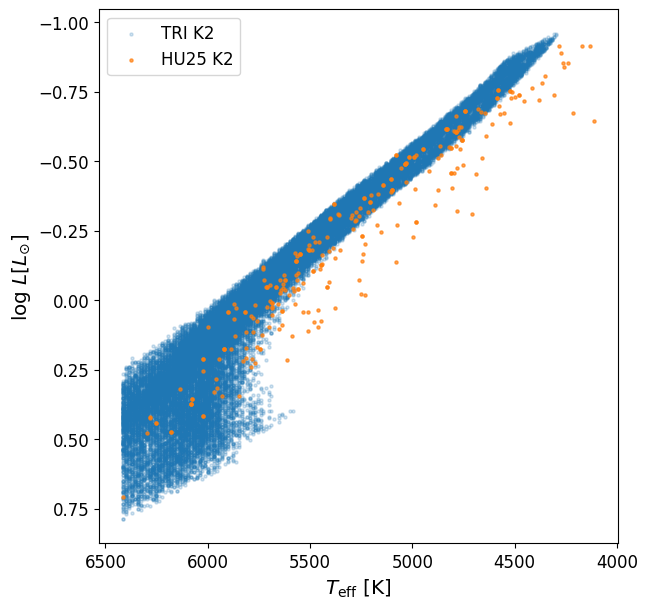

In [95]:
from matplotlib.gridspec import GridSpec

# figure and grid layout
fig = plt.figure(figsize=(8, 8))
gs = GridSpec(2, 3, figure=fig, wspace=0.05, hspace=0.05, width_ratios=[8, 1, 0.25], height_ratios=[1, 8]) # two horizontal assets, but third vertical asset required for colorbar

# main scatter plot spans bottom-left
ax_scatter = fig.add_subplot(gs[1, 0])

ax_scatter.scatter(tri_k2['Teff'], tri_k2['logL'], s=5, alpha=0.2, label='TRI K2')
ax_scatter.scatter(hu25_b26_culled['Teff_x'], np.log10(hu25_b26_culled['Lum']), s=5, alpha=0.7, label='HU25 K2')

ax_scatter.set_xlabel(r"$T_{\rm eff}$ [K]")
#ax_scatter.set_ylabel(r'$M_{K_{s}}$')
ax_scatter.set_ylabel(r'log $L [L_{\odot}]$')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
#ax_scatter.set_xlim([7600, 3900])
#ax_scatter.set_ylim([4.7, 3.6])
#ax_scatter.set_ylim([5.1, 1.1])
#plt.legend(fontsize='medium')
#plt.legend(loc='upper left', bbox_to_anchor=(0.02, 1.0), fontsize='medium')
plt.tight_layout()
plt.legend()
#plt.savefig(path+'plots/k2/hr_hu25_b26.png')
plt.show()

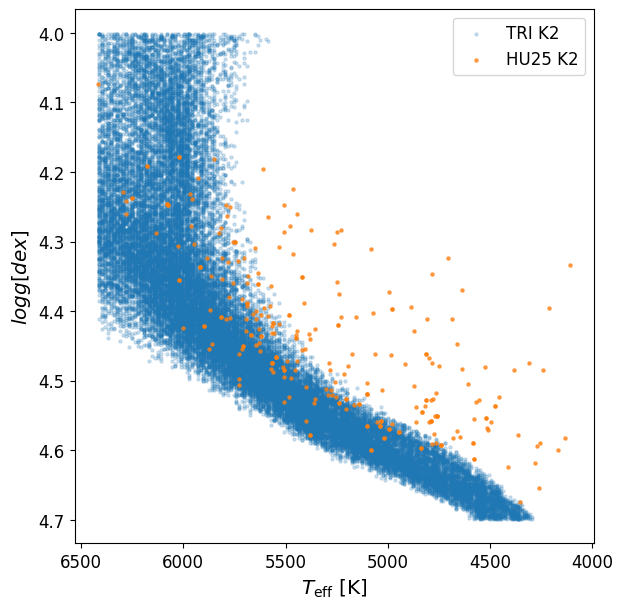

In [99]:
from matplotlib.gridspec import GridSpec

# figure and grid layout
fig = plt.figure(figsize=(8, 8))
gs = GridSpec(2, 3, figure=fig, wspace=0.05, hspace=0.05, width_ratios=[8, 1, 0.25], height_ratios=[1, 8]) # two horizontal assets, but third vertical asset required for colorbar

# main scatter plot spans bottom-left
ax_scatter = fig.add_subplot(gs[1, 0])

ax_scatter.scatter(tri_k2['Teff'], tri_k2['logg'], s=5, alpha=0.2, label='TRI K2')
ax_scatter.scatter(hu25_b26_culled['Teff_x'], hu25_b26_culled['logg_x'], s=5, alpha=0.7, label='HU25 K2')

ax_scatter.set_xlabel(r"$T_{\rm eff}$ [K]")
#ax_scatter.set_ylabel(r'$M_{K_{s}}$')
#ax_scatter.set_ylabel(r'($L [L_{\odot}]$)')
ax_scatter.set_ylabel(r'$log g [dex]$')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
#ax_scatter.set_xlim([7600, 3900])
#ax_scatter.set_ylim([4.7, 3.6])
#ax_scatter.set_ylim([5.1, 1.1])
#plt.legend(fontsize='medium')
#plt.legend(loc='upper left', bbox_to_anchor=(0.02, 1.0), fontsize='medium')
plt.tight_layout()
plt.legend()
#plt.savefig(path+'plots/k2/kiel_hu25_b26.png')
plt.show()

In [105]:
stem = 'data/kepler/trilegal/' 
filenames = os.listdir(path+stem)
filenames = [item for item in filenames if '.txt' in item] # omit directory name "luke"

tri_kepler = pd.DataFrame()
for i in range(len(filenames)):

	temp_kepler = pd.read_csv(path+stem+filenames[i], sep='\s+')
	temp_kepler.dropna(subset=['logAge','m2/m1'], inplace=True)

	# remove end lines from TRILEGAL, if applicable
	try:
		temp_kepler = temp_kepler[~temp_kepler['logAge'].str.contains('normally', na=False)]
	except:
		pass

	# add height column, introducing a spread of 0.05 dex based on TRILEGAL distance modulus bin size
	temp_kepler['distance'] = simulate_helpers.distance_modulus_to_distance(temp_kepler['m-M0'], perturb=True)
	temp_kepler['height'] = simulate_helpers.dist_kepler_to_height(temp_kepler['distance'])

	tri_kepler = pd.concat([tri_kepler, temp_kepler])

print("initial TRI: ", len(tri_kepler))

# remove binaries
tri_kepler = tri_kepler[tri_kepler['m2/m1']==0]
print("cut binaries: ", len(tri_kepler))

# unlog Teff. keep FGK dwarfs only
tri_kepler['Teff'] = 10**tri_kepler['logTe'].astype(float)
#tri_kepler = tri_kepler.loc[(tri_kepler['Teff'] <= 7500) & (tri_kepler['Teff'] >= 3900)] 
tri_kepler = tri_kepler.loc[(tri_kepler['Teff'] <= np.max(hu25_b20_culled['Teff'])) & (tri_kepler['Teff'] >= np.min(hu25_b20_culled['Teff']))] # match B20
print("Teff cut: ", len(tri_kepler))
print("max Teff: ", np.max(hu25_b20_culled['Teff']))
print("min Teff: ", np.min(hu25_b20_culled['Teff']))

# # calculate stellar radius
# tri_kepler['stellar_radius'] = simulate_helpers.stellar_radius_stefan_boltzmann(10**tri_kepler['logTe'], 10**tri_kepler['logL'])

# # remove giant based on B20 prescription
# tri_kepler['logR'] = np.log10(tri_kepler['stellar_radius'])
# tri_kepler['is_giant'] = np.where(tri_kepler['logR'] >= 0.00035*(tri_kepler['Teff'] - 4500) + 0.15, True, False)
# tri_kepler = tri_kepler.loc[tri_kepler['is_giant'] == False]
# print("cut giants: ", len(tri_kepler))

# remove poofy stars, same as B20
#tri_kepler = tri_kepler.loc[(tri_kepler['logg']<4.7) & (tri_kepler['logg']>3.6)]
tri_kepler = tri_kepler.loc[(tri_kepler['logg']<4.7) & (tri_kepler['logg']>4.)]
print("logg cut: ", len(tri_kepler))

# TRILEGAL logAge bin size is 0.02, so let's introduce a spread of that size; note from Luke Bouma (https://github.com/lgbouma/gyrojo/blob/main/gyrojo/trilegal.py#L92-L108)
eps = np.random.normal(loc=0, scale=0.02, size=len(tri_kepler))
tri_kepler['logAge'] = tri_kepler['logAge'].astype(float)
tri_kepler['logAge'] += eps
tri_kepler['age'] = 10**tri_kepler['logAge'].astype(float) / 1e9

# remove possible PMS stars
#tri_kepler = tri_kepler.loc[tri_kepler['age']>0.5]

# get rid of low metallicity stars because their Teff-logg relation is different
#tri_kepler = tri_kepler.loc[tri_kepler['[M/H]'].astype(float)>=-0.6] # this is different from Fe/H cut for B20, but we only have apples v oranges
#tri_kepler = tri_kepler.loc[tri_kepler['[M/H]'].astype(float)<=0.3] # this is different from Fe/H cut for B20, but we only have apples v oranges
tri_kepler = tri_kepler.loc[tri_kepler['[M/H]'].astype(float)>=-0.25] # this is different from Fe/H cut for B20, but we only have apples v oranges
tri_kepler = tri_kepler.loc[tri_kepler['[M/H]'].astype(float)<=0.25]
print("metallicity cut: ", len(tri_kepler))

# same age cut as B20
tri_kepler = tri_kepler.loc[tri_kepler['age'] <= 14.] 
print("min age: ", np.min(hu25_b26_culled['Age']))
tri_kepler = tri_kepler.loc[tri_kepler['age'] >= np.min(hu25_b26_culled['Age'])] 
print("age cut: ", len(tri_kepler))

# # make an additional cut on Kepler magnitude
# tri_kepler = tri_kepler.loc[(tri_kepler['Kepler'] <= np.max(kepler_stars_bedell_df_kepmag['kepmag'])) & (tri_kepler['Kepler'] >= np.min(kepler_stars_bedell_df_kepmag['kepmag']))] 
# print("kepmag cut: ", len(tri_kepler))
# print("min kepmag: ", np.min(kepler_stars_bedell_df_kepmag['kepmag']))
# print("max kepmag: ", np.max(kepler_stars_bedell_df_kepmag['kepmag']))

# extrapolate CDPP based on Zink+20
#my_k2 = simulate_helpers.kepmag_to_cdpp_vectorized(k2_stars, my_k2) # cdpp distribution is similar to B20 sample

tri_kepler = tri_kepler.reset_index()
tri_kepler


initial TRI:  280647
cut binaries:  132951
Teff cut:  124203
max Teff:  7289
min Teff:  4365
logg cut:  86358
metallicity cut:  57736
min age:  0.531
age cut:  55108


,index,#Gc,logAge,[M/H],m_ini,logL,logTe,logg,m-M0,Av,...,z,DDO51_finf,J,H,Ks,Mact,distance,height,Teff,age
0,1109,1,8.733675,-0.19,1.01557,-0.053,3.766,4.509,9.595616,0.032,...,14.344,14.740,13.469,13.158,13.118,1.016,830.086054,193.779741,5834.451043,0.541595
1,1235,1,8.736862,-0.01,0.96814,-0.200,3.740,4.530,10.551521,0.036,...,15.596,16.167,14.665,14.293,14.243,0.968,1289.152154,300.946594,5495.408739,0.545584
2,1256,1,8.742473,0.17,0.89040,-0.425,3.704,4.574,8.690106,0.027,...,14.241,15.128,13.226,12.766,12.699,0.890,547.042653,127.704571,5058.246620,0.552679
3,1277,1,8.752844,-0.13,1.42379,0.682,3.857,4.284,10.193609,0.034,...,13.351,13.274,12.638,12.516,12.495,1.424,1093.255993,255.215543,7194.489780,0.566036
4,1293,1,8.742958,-0.01,1.05845,-0.001,3.764,4.466,10.390458,0.035,...,14.851,15.267,13.972,13.658,13.617,1.058,1196.993208,279.432515,5807.644175,0.553297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55103,30326,1,9.869405,0.05,1.02004,0.201,3.763,4.242,11.282365,0.037,...,15.389,15.811,14.507,14.195,14.152,1.020,1804.982878,421.364885,5794.286964,7.402959
55104,30329,1,9.916519,0.07,1.03975,0.270,3.762,4.180,11.206546,0.037,...,14.965,15.391,14.082,13.771,13.727,1.040,1743.047564,406.906373,5780.960474,8.251228
55105,30330,1,9.913439,0.07,1.05126,0.316,3.761,4.134,11.449510,0.037,...,15.248,15.679,14.362,14.048,14.004,1.051,1949.404274,455.079390,5767.664634,8.192921
55106,30332,1,9.907678,0.09,1.05186,0.309,3.760,4.137,11.225063,0.037,...,14.960,15.400,14.073,13.757,13.713,1.052,1757.974838,410.391076,5754.399373,8.084954


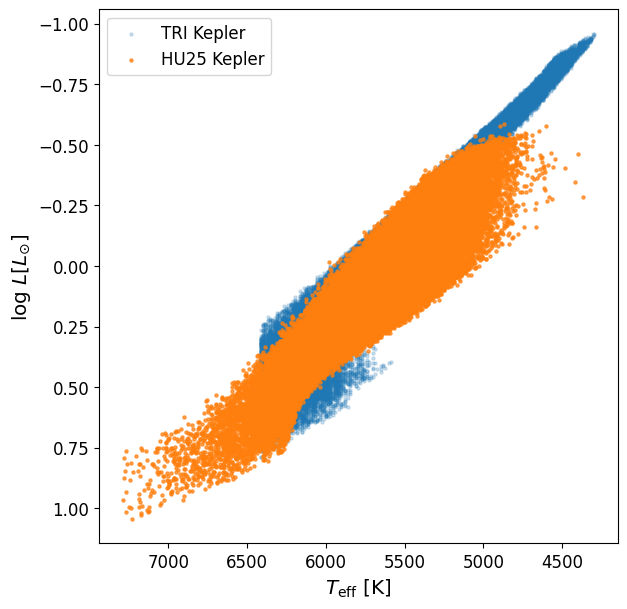

In [106]:
from matplotlib.gridspec import GridSpec

# figure and grid layout
fig = plt.figure(figsize=(8, 8))
gs = GridSpec(2, 3, figure=fig, wspace=0.05, hspace=0.05, width_ratios=[8, 1, 0.25], height_ratios=[1, 8]) # two horizontal assets, but third vertical asset required for colorbar

# main scatter plot spans bottom-left
ax_scatter = fig.add_subplot(gs[1, 0])

ax_scatter.scatter(tri_k2['Teff'], tri_k2['logL'], s=5, alpha=0.2, label='TRI Kepler')
ax_scatter.scatter(hu25_b20_culled['Teff'], np.log10(hu25_b20_culled['Lum']), s=5, alpha=0.7, label='HU25 Kepler')

ax_scatter.set_xlabel(r"$T_{\rm eff}$ [K]")
#ax_scatter.set_ylabel(r'$M_{K_{s}}$')
ax_scatter.set_ylabel(r'log $L [L_{\odot}]$')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
#ax_scatter.set_xlim([7600, 3900])
#ax_scatter.set_ylim([4.7, 3.6])
#ax_scatter.set_ylim([5.1, 1.1])
#plt.legend(fontsize='medium')
#plt.legend(loc='upper left', bbox_to_anchor=(0.02, 1.0), fontsize='medium')
plt.tight_layout()
plt.legend()
#plt.savefig(path+'plots/k2/hr_hu25_b26.png')
plt.show()

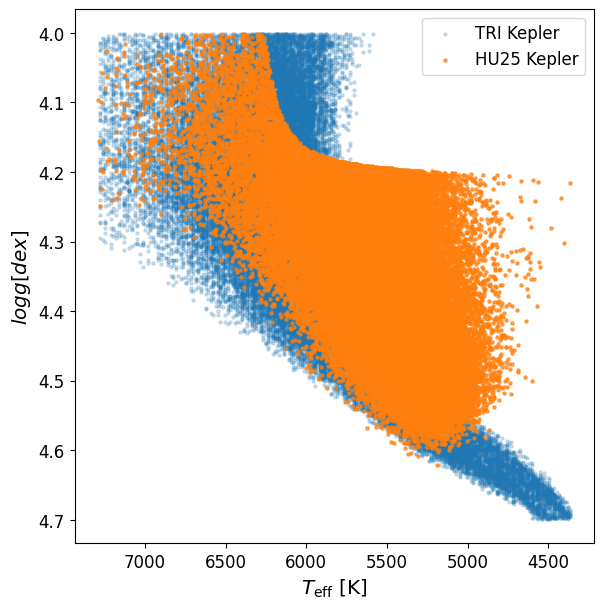

In [112]:
from matplotlib.gridspec import GridSpec

# figure and grid layout
fig = plt.figure(figsize=(8, 8))
gs = GridSpec(2, 3, figure=fig, wspace=0.05, hspace=0.05, width_ratios=[8, 1, 0.25], height_ratios=[1, 8]) # two horizontal assets, but third vertical asset required for colorbar

# main scatter plot spans bottom-left
ax_scatter = fig.add_subplot(gs[1, 0])

ax_scatter.scatter(tri_kepler['Teff'], tri_kepler['logg'], s=5, alpha=0.2, label='TRI Kepler')
ax_scatter.scatter(hu25_b20_culled['Teff'], hu25_b20_culled['logg'], s=5, alpha=0.7, label='HU25 Kepler')

ax_scatter.set_xlabel(r"$T_{\rm eff}$ [K]")
#ax_scatter.set_ylabel(r'$M_{K_{s}}$')
#ax_scatter.set_ylabel(r'($L [L_{\odot}]$)')
ax_scatter.set_ylabel(r'$log g [dex]$')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
#ax_scatter.set_xlim([7600, 3900])
#ax_scatter.set_ylim([4.7, 3.6])
#ax_scatter.set_ylim([5.1, 1.1])
#plt.legend(fontsize='medium')
#plt.legend(loc='upper left', bbox_to_anchor=(0.02, 1.0), fontsize='medium')
plt.tight_layout()
plt.legend()
#plt.savefig(path+'plots/k2/kiel_hu25_b26.png')
plt.show()

Compare ages

In [151]:
tri_kepler['Age'] = 10**tri_kepler['logAge'].astype(float) / 1e9
tri_k2['Age'] = 10**tri_k2['logAge'].astype(float) / 1e9

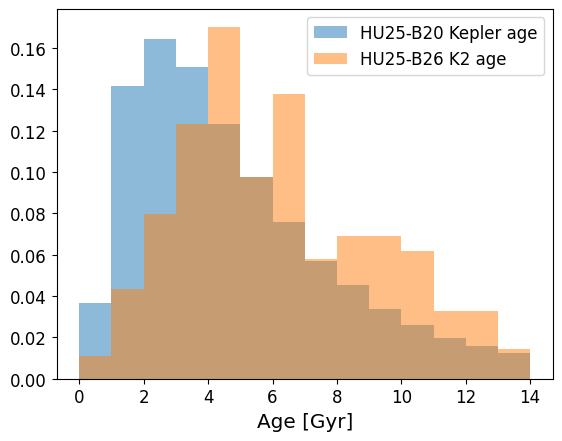

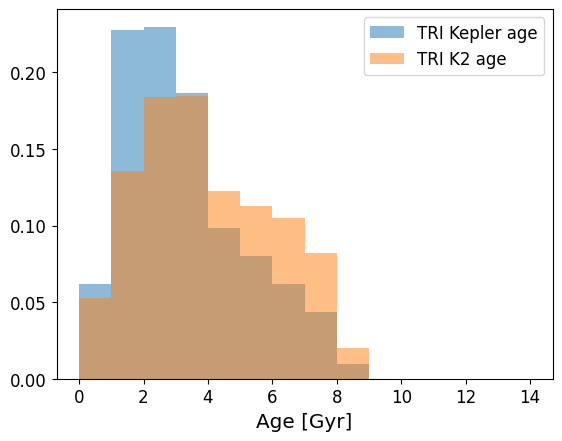

In [152]:
plt.hist(hu25_b20_culled.iso_age, bins=np.linspace(0, 14, 15), density=True, alpha=0.5, label='HU25-B20 Kepler age')
plt.hist(hu25_b26_culled.Age, bins=np.linspace(0, 14, 15), density=True, alpha=0.5, label='HU25-B26 K2 age')
plt.xlabel('Age [Gyr]')
plt.legend()
plt.show()

plt.hist(tri_kepler.Age, bins=np.linspace(0, 14, 15), density=True, alpha=0.5, label='TRI Kepler age')
plt.hist(tri_k2.Age, bins=np.linspace(0, 14, 15), density=True, alpha=0.5, label='TRI K2 age')
plt.xlabel('Age [Gyr]')
plt.legend()
plt.show()

In [167]:
total_tri = pd.concat([tri_kepler, tri_k2])

hu25_b26_culled = hu25_b26_culled.rename(columns={'Teff_x': 'Teff'})
hu25_b26_culled = hu25_b26_culled.rename(columns={'logg_x': 'logg'})

hu25_b20_culled = hu25_b20_culled.rename(columns={'iso_age': 'Age'})
total_hu25 = pd.concat([hu25_b20_culled, hu25_b26_culled])



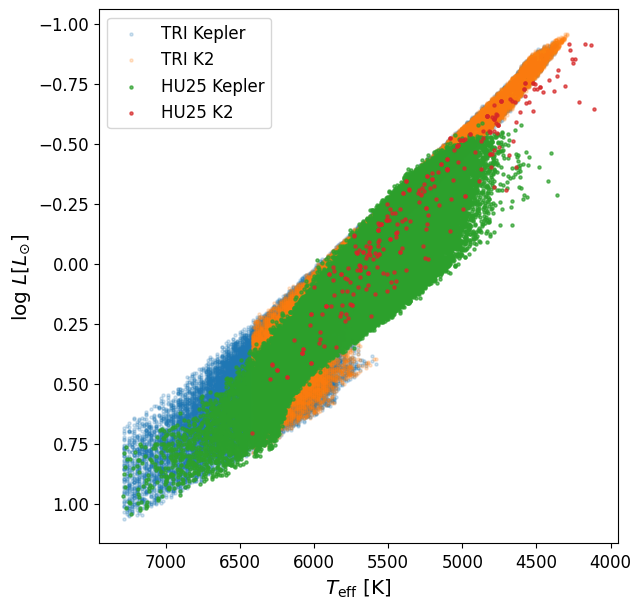

In [118]:
from matplotlib.gridspec import GridSpec

# figure and grid layout
fig = plt.figure(figsize=(8, 8))
gs = GridSpec(2, 3, figure=fig, wspace=0.05, hspace=0.05, width_ratios=[8, 1, 0.25], height_ratios=[1, 8]) # two horizontal assets, but third vertical asset required for colorbar

# main scatter plot spans bottom-left
ax_scatter = fig.add_subplot(gs[1, 0])

ax_scatter.scatter(tri_kepler['Teff'], tri_kepler['logL'], s=5, alpha=0.2, label='TRI Kepler')
ax_scatter.scatter(tri_k2['Teff'], tri_k2['logL'], s=5, alpha=0.2, label='TRI K2')
ax_scatter.scatter(hu25_b20_culled['Teff'], np.log10(hu25_b20_culled['Lum']), s=5, alpha=0.7, label='HU25 Kepler')
ax_scatter.scatter(hu25_b26_culled['Teff'], np.log10(hu25_b26_culled['Lum']), s=5, alpha=0.7, label='HU25 K2')

ax_scatter.set_xlabel(r"$T_{\rm eff}$ [K]")
#ax_scatter.set_ylabel(r'$M_{K_{s}}$')
ax_scatter.set_ylabel(r'log $L [L_{\odot}]$')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
#ax_scatter.set_xlim([7600, 3900])
#ax_scatter.set_ylim([4.7, 3.6])
#ax_scatter.set_ylim([5.1, 1.1])
#plt.legend(fontsize='medium')
#plt.legend(loc='upper left', bbox_to_anchor=(0.02, 1.0), fontsize='medium')
plt.tight_layout()
plt.legend()
#plt.savefig(path+'plots/k2/hr_hu25_b26.png')
plt.show()

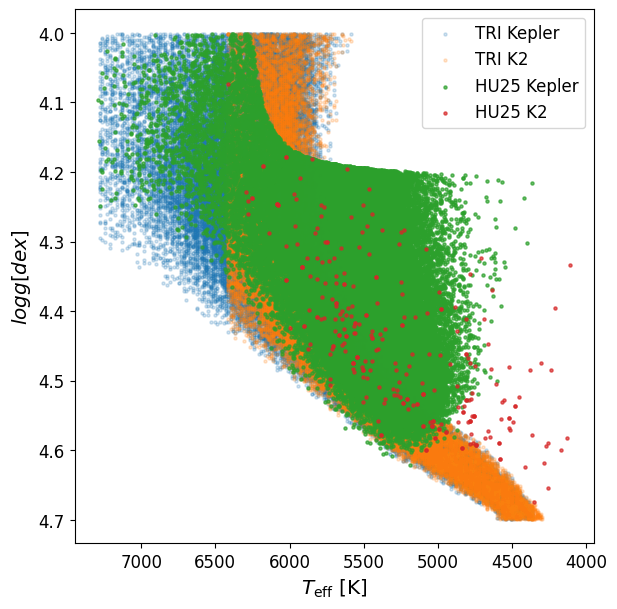

In [124]:
from matplotlib.gridspec import GridSpec

# figure and grid layout
fig = plt.figure(figsize=(8, 8))
gs = GridSpec(2, 3, figure=fig, wspace=0.05, hspace=0.05, width_ratios=[8, 1, 0.25], height_ratios=[1, 8]) # two horizontal assets, but third vertical asset required for colorbar

# main scatter plot spans bottom-left
ax_scatter = fig.add_subplot(gs[1, 0])

ax_scatter.scatter(tri_kepler['Teff'], tri_kepler['logg'], s=5, alpha=0.2, label='TRI Kepler')
ax_scatter.scatter(tri_k2['Teff'], tri_k2['logg'], s=5, alpha=0.2, label='TRI K2')
ax_scatter.scatter(hu25_b20_culled['Teff'], hu25_b20_culled['logg'], s=5, alpha=0.7, label='HU25 Kepler')
ax_scatter.scatter(hu25_b26_culled['Teff'], hu25_b26_culled['logg'], s=5, alpha=0.7, label='HU25 K2')

ax_scatter.set_xlabel(r"$T_{\rm eff}$ [K]")
#ax_scatter.set_ylabel(r'$M_{K_{s}}$')
#ax_scatter.set_ylabel(r'($L [L_{\odot}]$)')
ax_scatter.set_ylabel(r'$log g [dex]$')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
#ax_scatter.set_xlim([7600, 3900])
#ax_scatter.set_ylim([4.7, 3.6])
#ax_scatter.set_ylim([5.1, 1.1])
#plt.legend(fontsize='medium')
#plt.legend(loc='upper left', bbox_to_anchor=(0.02, 1.0), fontsize='medium')
plt.tight_layout()
plt.legend()
#plt.savefig(path+'plots/k2/kiel_hu25_b26.png')
plt.show()

K-S Tests

- K-S test: K-S statistic tells us how big the maximum CDF difference is; p-value tells us how confident we are. 0.1-0.2 is considered moderate. Range is 0-1.
- A-D test: A-D statistic tells us how the CDF tails differ. A^2 is not bounded. Greater than 2 is getting towards different distributions. 

In [130]:
from scipy.stats import ks_2samp
from scipy.stats import anderson_ksamp

ks_stat, p_value = ks_2samp(total_hu25['Teff'], total_tri['Teff'])
print("K-S Teff: ", ks_stat, p_value)

ks_stat, p_value = ks_2samp(total_hu25['logg'], total_tri['logg'])
print("K-S logg: ", ks_stat, p_value)

result = anderson_ksamp([total_hu25['Teff'], total_tri['Teff']])
print("A-D Teff: ", result.statistic, result.significance_level)

result = anderson_ksamp([total_hu25['logg'], total_tri['logg']])
print("A-D logg: ", result.statistic, result.significance_level)


K-S Teff:  0.42413704586655016 0.0
K-S logg:  0.15852198019927843 0.0
A-D Teff:  13586.727204355551 0.001
A-D logg:  3360.2255612198023 0.001


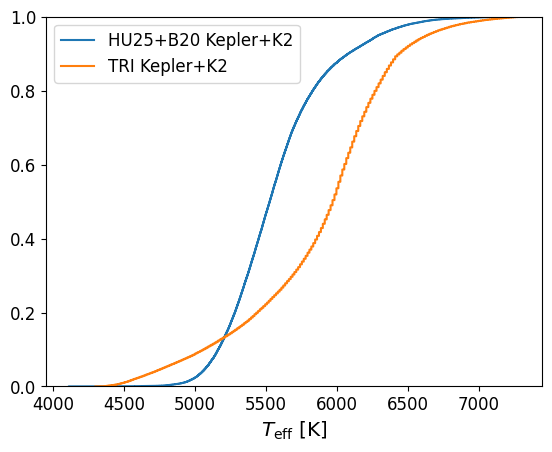

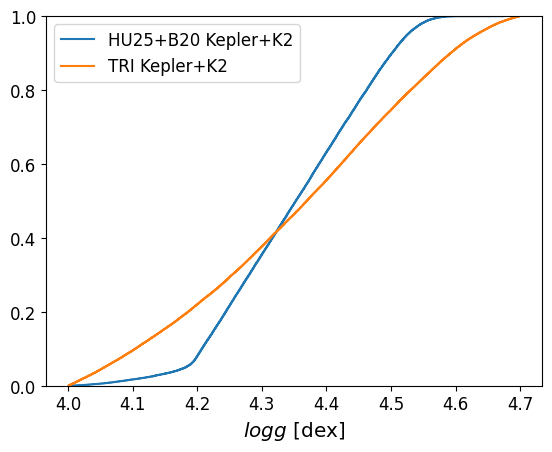

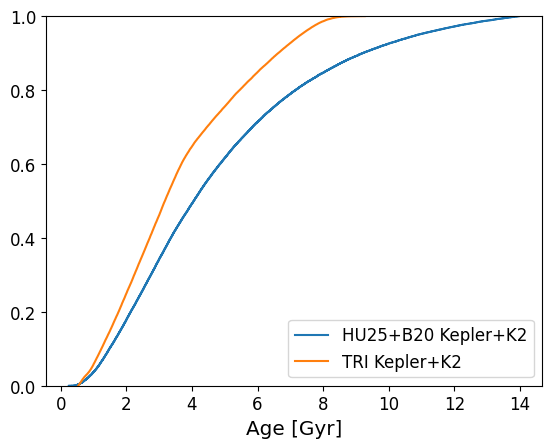

In [163]:
plt.ecdf(total_hu25['Teff'], label='HU25+B20 Kepler+K2')
plt.ecdf(total_tri['Teff'], label='TRI Kepler+K2')
plt.xlabel(r"$T_{\rm eff}$ [K]")
plt.legend()   
plt.show()

plt.ecdf(total_hu25['logg'], label='HU25+B20 Kepler+K2')
plt.ecdf(total_tri['logg'], label='TRI Kepler+K2')
plt.xlabel(r"$log g$ [dex]")
plt.legend()   
plt.show()

plt.ecdf(total_hu25['Age'], label='HU25+B20 Kepler+K2')
plt.ecdf(total_tri['Age'], label='TRI Kepler+K2')
plt.xlabel(r"Age [Gyr]")
plt.legend()
plt.show()

Compare Zmax vs age

In [168]:
def gala_galactic_heights_k2(df, output=True):


    """
    Use Gala (Price-Whelan+) to simulate orbits of Gaia stars and get their Z_maxes
    """

    """
    # merge sample with Megan Bedell's Gaia-Kepler cross-match because those save info on RV, proper motion, parallax, etc required for Gala
    berger = Table.read(path+'data/berger_kepler_stellar_fgk.csv')
    megan = Table.read(path+'data/kepler_dr3_good.fits')
    merged = join(berger, megan, keys='kepid')
    merged.rename_column('parallax_2', 'parallax')
    #print(merged[['parallax', 'parallax_error', 'radial_velocity', 'radial_velocity_error']])
    """

    df['radial_velocity'] = np.random.normal(df['radial_velocity'], df['radial_velocity_error'])
    df['pmra'] = np.random.normal(df['pmra'], df['pmra_error'])
    df['pmdec'] = np.random.normal(df['pmdec'], df['pmdec_error'])
    df['parallax'] = np.random.normal(df['parallax'], df['parallax_error'])

    # mise en place
    with coord.galactocentric_frame_defaults.set("v4.0"):
        galcen_frame = coord.Galactocentric()

    sun_xyz = u.Quantity(
        [-galcen_frame.galcen_distance, 0 * u.kpc, galcen_frame.z_sun]  # x  # y  # z
    )

    sun_w0 = gd.PhaseSpacePosition(pos=sun_xyz, vel=galcen_frame.galcen_v_sun)

    mw_potential = gp.MilkyWayPotential()

    sun_orbit = mw_potential.integrate_orbit(sun_w0, dt=0.5 * u.Myr, t1=0, t2=4 * u.Gyr)

    star_gaia = GaiaData(df)

    star_gaia_c = star_gaia.get_skycoord()
    star_galcen = star_gaia_c.transform_to(galcen_frame)
    star_w0 = gd.PhaseSpacePosition(star_galcen.data)

    # calculate orbits and retrieve Z_maxes
    zmaxes = []
    for i in tqdm(range(len(star_gaia))):
    #for i in range(1000):
        star_orbit = mw_potential.integrate_orbit(star_w0[i], t=sun_orbit.t) 
        zmax = star_orbit.zmax().value
        zmaxes.append(zmax)

    zmaxes_df = pd.DataFrame({'height': zmaxes})
    #zmaxes_df.to_csv(path+'data/zmaxes.csv', index=False)
    
    return zmaxes


# remove stars without full astrometric solution
bedell = Table.read(path+'data/kepler_dr3_good.fits')
bedell_df = bedell.to_pandas()
total_hu25 = pd.merge(total_hu25, bedell_df[['kepid', 'ra', 'dec', 'parallax', 'parallax_error', 'pmra', 'pmra_error', 'pmdec', 'pmdec_error', 'radial_velocity', 'radial_velocity_error']], left_on='Kepler_ID', right_on='kepid', how='left')
total_hu25 = total_hu25.dropna(subset=['parallax', 'parallax_error', 'ra', 'dec', 'pmra', 'pmra_error', 'pmdec', 'pmdec_error', 'radial_velocity', 'radial_velocity_error'])
print("astrometric solution cut: ", len(total_hu25))

total_hu25['height'] = gala_galactic_heights_k2(Table.from_pandas(total_hu25))

astrometric solution cut:  22971


100%|██████████| 22971/22971 [02:16<00:00, 168.79it/s]


3        7.44
6        3.20
7        2.13
8        3.73
10       8.44
         ... 
54097    2.35
54099    1.12
54101    1.81
54103    3.01
54106    1.45
Name: Age, Length: 22971, dtype: float64
3        293.104574
6        340.628489
7        612.293782
8        264.058346
10       619.385474
            ...    
54097    542.743293
54099    308.758782
54101    179.278938
54103    176.006909
54106    131.890250
Name: height, Length: 22971, dtype: float64


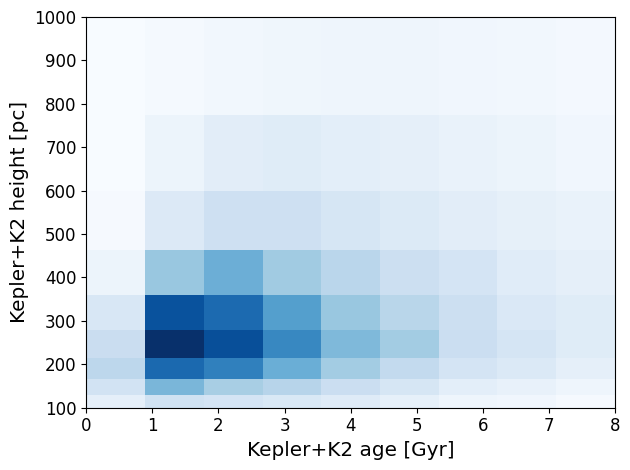

In [170]:
bins2d = [np.linspace(0, 8, 10), np.logspace(2, 3, 10)]

label='HU25'
ages = total_hu25['Age']
heights = total_hu25['height']*1000
norm = 10
print(ages)
print(heights)
hist, xedges, yedges = np.histogram2d(ages, heights, bins=bins2d)
hist = hist.T

normalized = False
if normalized==True:
	with np.errstate(divide='ignore', invalid='ignore'):  # suppress division by zero warnings
		hist *= norm / hist.sum(axis=0, keepdims=True)
		#hist *= norm / hist.sum(axis=1, keepdims=True)
if label=='TRI':
	ax = plt.pcolormesh(xedges, yedges, hist, cmap='Blues')
	plt.xlabel('TRILEGAL age [Gyr]')
	plt.ylabel('TRILEGAL height [pc]')
elif label=='HU25':
	ax = plt.pcolormesh(xedges, yedges, hist, cmap='Blues')
	plt.xlabel('Kepler+K2 age [Gyr]')
	plt.ylabel('Kepler+K2 height [pc]')
#plt.legend(bbox_to_anchor=(1., 1.05))
plt.tight_layout()
#plt.savefig(path+'plots/k2/age_vs_height_B20_bootstrapped.png')
plt.show()

0        0.541595
1        0.545584
2        0.552679
3        0.566036
4        0.553297
           ...   
35975    8.256662
35976    8.139880
35977    8.274857
35978    8.854365
35979    8.338928
Name: Age, Length: 91088, dtype: float64
0         193.779741
1         300.946594
2         127.704571
3         255.215543
4         279.432515
            ...     
35975     608.043711
35976     768.820933
35977    1373.658810
35978    1378.842869
35979     520.630496
Name: height, Length: 91088, dtype: float64


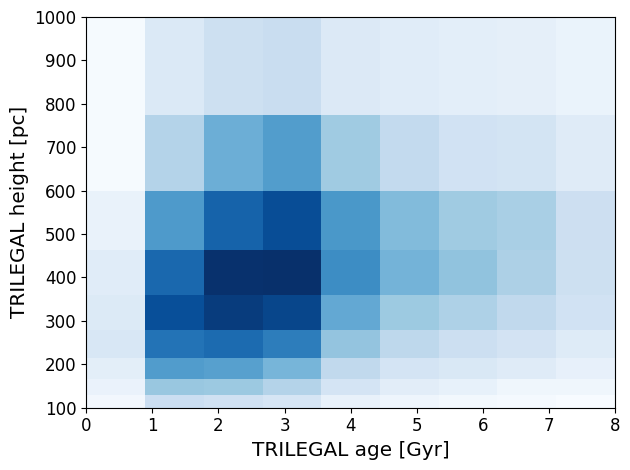

In [171]:
bins2d = [np.linspace(0, 8, 10), np.logspace(2, 3, 10)]

label='TRI'
ages = total_tri['Age']
heights = total_tri['height']
norm = 10
print(ages)
print(heights)
hist, xedges, yedges = np.histogram2d(ages, heights, bins=bins2d)
hist = hist.T

normalized = False
if normalized==True:
	with np.errstate(divide='ignore', invalid='ignore'):  # suppress division by zero warnings
		hist *= norm / hist.sum(axis=0, keepdims=True)
		#hist *= norm / hist.sum(axis=1, keepdims=True)
if label=='TRI':
	ax = plt.pcolormesh(xedges, yedges, hist, cmap='Blues')
	plt.xlabel('TRILEGAL age [Gyr]')
	plt.ylabel('TRILEGAL height [pc]')
elif label=='HU25':
	ax = plt.pcolormesh(xedges, yedges, hist, cmap='Blues')
	plt.xlabel('Kepler+K2 age [Gyr]')
	plt.ylabel('Kepler+K2 height [pc]')
#plt.legend(bbox_to_anchor=(1., 1.05))
plt.tight_layout()
#plt.savefig(path+'plots/k2/age_vs_height_B20_bootstrapped.png')
plt.show()

Bootstrap

In [108]:
def draw_asymmetrically(df, mode_name, err1_name, err2_name, drawn):
    """
    Draw stellar properties with asymmetric errors. 
    This is the generalized version of draw_star_ages(), below
    
    Inputs:
    - df: berger_kepler [Pandas DataFrame]
    - mode_name: name of mode column [string]
    - err1_name: name of err1 column [string]
    - err2_name: name of err2 column [string]
    - drawn: name of new column [string]

    Output:
    - df: berger_kepler_df, now with new column with drawn parameter, "drawn" [Pandas DataFrame]
    """

    # in case df is broken up by planet and not star
    uniques = df
    
    if drawn=='age':
        x = np.linspace(0.5, 13.5, 100)
    elif drawn=='gyro_age':
        x = np.linspace(0.5, 4., 100)
    elif drawn=='stellar_radius':
        x = np.linspace(0.5, 5., 100)
    elif drawn=='stellar_mass':
        x = np.linspace(0.5, 2.5, 100)
    elif drawn=='Teff':
        x = np.linspace(3400, 8000, 1000) # x = np.linspace(3700, 7500, 1000); Z23 did (4000, 6500, 1000); originally I did (5300, 7500), but let's just make cuts separately
    elif drawn=='stellar_feh':
        x = np.linspace(-0.5, 0.5, 100)
    elif drawn=='distance':
        x = np.linspace(0, 5000, 1000)
    elif drawn=='planet_radius':
        x = np.linspace(0.5, 10, 100)
    elif drawn=='logg':
        x = np.linspace(3., 5., 1000)  # formerly 3.6 to 4.7 over 100, but there were sampling artifacts due to low resolution and incomplete coverage

    else: 
        print("Please create a column that is either age, gyro_age, stellar_radius, stellar_mass, distance, planet_radius, stellar_feh, or stellar_teff!")

    """
    TESTING
    print("x: ", x)
    pdf = make_pdf_rows(x, mode, err1, err2)
    pdf = pdf/np.sum(pdf)
    draw = np.around(np.random.choice(x, p=pdf), 2)
    print("draw: ", draw)
    """

    if drawn=='planet_radius':
        df_or_uniques = df
    else:
        df_or_uniques = uniques

    draws = np.ones(len(df_or_uniques))
    for i in range(len(df_or_uniques)):
        mode = df_or_uniques.iloc[i][mode_name]
        err1 = df_or_uniques.iloc[i][err1_name]
        err2 = np.abs(df_or_uniques.iloc[i][err2_name])
        
        #"""
        # symmetric uncertainties
        if err1==err2:
            if drawn!='stellar_feh':
                draw = 0
                while draw <= 0: # make sure the draw is positive
                    draw = np.random.normal(mode, err1) # I used to round this to two decimal places but I don't know why I did this.
            elif drawn=='stellar_feh':
                draw = np.random.normal(mode, err1)

        # asymmetric uncertainties
        elif err1!=err2:
            try:
                pdf = make_pdf_rows(x, mode, err1, err2)
                pdf = pdf/np.sum(pdf)
            except Exception as e:
                print(e)
                print(x, mode, err1, err2)

            try:
                if drawn!='stellar_feh':
                    draw = 0
                    while draw <= 0: # make sure the draw is positive
                        draw = np.random.choice(x, p=pdf)
                elif drawn=='stellar_feh':
                    draw = np.random.choice(x, p=pdf)
            except Exception as e:
                #print("EXCEPTION: ", i, pdf, mode, err1, err2)
                #print(e)
                continue
        #"""
        #if draw==1.:
        #    print(draw, mode, err1, err2)
        
        """
        ### make all draws the same way, symmetric or asymmetric
        pdf = make_pdf_rows(x, mode, err1, err2)
        pdf = pdf/np.sum(pdf)

        try:
            draw = 0
            while draw <= 0: # make sure the draw is positive
                draw = np.around(np.random.choice(x, p=pdf), 2)
        except Exception as e:
            print("EXCEPTION: ", i, pdf, mode, err1, err2)
            print(e)
            break
        """

        #print(mode, err1, err2, draw)
        draws[i] = draw

    #print(len(df), len(draws), len(uniques))
    df_or_uniques[drawn] = draws

    # break back out into planet rows and forward fill across systems
    #df = uniques.merge(df, how='right')
    #df[drawn] = df[drawn].fillna(method='ffill')
    
    return df_or_uniques

### adapted from The Cannon project with Aida
def tighter_cull(comparison_df, comparison_teff, comparison_logg):

    comparison_df = comparison_df.loc[((comparison_logg<4.4) & (comparison_teff<6300))]
    comparison_df = comparison_df.loc[((comparison_logg>3.4) & (comparison_teff>5300))]

    return comparison_df

def make_pdf_rows(x, mode, err1, err2):
    """
    Row-wise likelihood of asymmetric uncertainty, using Eqn 6 from https://iopscience.iop.org/article/10.3847/1538-3881/abd93f
    Less efficient, but row-wise in order to troubleshoot. 
    Takes in scalar values for mode, err1, and err2, not arrays.

    Input:
    - x: np.linspace(0.5, 10, 100); just something to undergird the PDF and represent stellar ages
    - mode: mean age; peak of asymmetric PDF
    - err1: + uncertainty
    - err2: - uncertainty (note: must be positive)

    Output:
    - pdf: asymmetric PDF

    """
    
    factor1 = 1/np.sqrt(2*np.pi*err1**2) 
    beta = err1/err2
    gamma = (err1 - np.abs(err2))/(err1 * np.abs(err2))
    
    factor2_arg_a = np.log(1+gamma*(x - mode))
    factor2_arg_b = np.log(beta)
    factor2_arg = factor2_arg_a/factor2_arg_b
    factor2 = np.exp(-0.5*(factor2_arg)**2)

    out = factor1 * factor2
    out[~np.isfinite(out)] = 0.0
    
    return out


In [180]:
# # all data downloaded from Berger et al 2020's ancillary tables: https://arxiv.org/src/2001.07737v3/anc
# the paper we're comparing against: https://arxiv.org/pdf/2005.14671.pdf
# command line edit to get rid of double backslashes at end of each row: sed -e "s/\\\//g" GKSPCPapTable2_Final.txt > GKSPCPapTable2_cleaned.txt
table2 = pd.read_csv(path+'data/GKSPCPapTable2_cleaned.txt', sep='&', header=0)
print(len(table2))

# remove stars with unreliable ages or bad goodness of fit
table2 = table2.loc[(table2.unReAgeFlag.isnull()) & (table2.iso_gof==1.)]
print("unreliable age cut: ", len(table2))

# remove stars with uninformative posteriors (per paper, terminal age of main sequence > 20 Gyr). REDUNDANT TO ABOVE CUT
#table2 = table2.loc[table2['TAMS']<=20]	

# make fractional age errors up front because they are based on iso_age_error/iso_age, not the drawn ages
table2['fractional_err1'] = table2.iso_age_err1/table2.iso_age
table2['fractional_err2'] = table2.iso_age_err2/table2.iso_age
print(np.nanmedian(table2.iso_age_err1/table2.iso_age))
print(np.nanmedian(table2.iso_age_err2/table2.iso_age))
table2 = table2.loc[table2.fractional_err1 <= 0.50]
table2 = table2.loc[np.abs(table2.fractional_err2) <= 0.40]
print("age uncertainty cut: ", len(table2))

# introduce Table 1 to use RUWE (re-normalized unit-weight error), aka binary star/edge-of-parameter space classifier
# command line edit to get rid of double backslashes at end of each row: sed -e "s/\\\//g" GKSPCPapTable1_Final.txt > GKSPCPapTable1_cleaned.txt
table1 = pd.read_csv(path+'data/GKSPCPapTable1_cleaned.txt', sep='&', header=0)
table1 = table1.loc[table1.RUWE<=1.2]

catalog = pd.merge(table2, table1, how='inner', on='KIC')
print("binary cut: ", len(catalog))

# remove stars without full astrometric solution
bedell = Table.read(path+'data/kepler_dr3_good.fits')
bedell_df = bedell.to_pandas()
catalog = pd.merge(catalog, bedell_df[['kepid', 'ra', 'dec', 'parallax_error', 'pmra', 'pmra_error', 'pmdec', 'pmdec_error', 'radial_velocity', 'radial_velocity_error']], left_on='KIC', right_on='kepid', how='left')
catalog = catalog.dropna(subset=['parallax', 'parallax_error', 'ra', 'dec', 'pmra', 'pmra_error', 'pmdec', 'pmdec_error', 'radial_velocity', 'radial_velocity_error'])
print("astrometric solution cut: ", len(catalog))

# cross-match with HU25
hu25_b20 = pd.merge(catalog, kepler_stars, left_on='KIC', right_on='Kepler_ID', how='inner')
print("cross match with HU25: ", len(hu25_b20))
#list(hu25_b20.columns)


186301
unreliable age cut:  150560
0.4990941999258294
-0.395
age uncertainty cut:  68810
binary cut:  60386
astrometric solution cut:  32073
cross match with HU25:  9278


In [204]:
print("initial B26 K2: ", len(b26_k2))

# age reliability cut
#b26_k2_cull = b26_k2.loc[b26_k2['Age']+b26_k2['E_Age']<=20.] # make sure 75th percentile age is less than 20 Gyr
#print("realistic age cut: ", len(b26_k2_cull))

# fractional age cuts
b26_k2['fractional_err1'] = b26_k2.E_Age/b26_k2.Age 
b26_k2['fractional_err2'] = b26_k2.e_Age/b26_k2.Age
print("median fractional err1: ", np.nanmedian(b26_k2.fractional_err1))
print("median fractional err2: ", np.nanmedian(b26_k2.fractional_err2))
#b26_k2_cull = b26_k2.loc[(b26_k2.fractional_err1 <= 0.50) & (np.abs(b26_k2.fractional_err2) <= 0.40)]
b26_k2_cull = b26_k2.loc[(b26_k2.fractional_err1 <= 0.93) & (np.abs(b26_k2.fractional_err2) <= 0.71)]
print("fractional age uncertainty cut: ", len(b26_k2_cull))

# cross match with HU25
hu25_b26 = pd.merge(b26_k2_cull, k2_stars, left_on='EPIC', right_on='EPIC_ID', how='inner')
print("cross match with HU25: ", len(hu25_b26))

# enrich with astrometric info from Gaia DR3
from astroquery.gaia import Gaia

# list of Gaia DR3 source IDs
k2_source_ids = list(hu25_b26['DR3'])

# convert to ADQL list
k2_source_list = ",".join(str(s) for s in k2_source_ids)

query = f"""
SELECT source_id,
       ra, dec,
       parallax,
       pmra, pmdec,
       radial_velocity,
	   ra_error, dec_error, parallax_error, pmra_error, pmdec_error, radial_velocity_error
FROM gaiadr3.gaia_source
WHERE source_id IN ({k2_source_list})
"""

job = Gaia.launch_job_async(query)
results = job.get_results()

k2_astrometry = results.to_pandas()
k2_astrometry




initial B26 K2:  618
median fractional err1:  0.9315043503563742
median fractional err2:  0.7136483228780531
fractional age uncertainty cut:  260
cross match with HU25:  137
INFO: Query finished. [astroquery.utils.tap.core]


,SOURCE_ID,ra,dec,parallax,pmra,pmdec,radial_velocity,ra_error,dec_error,parallax_error,pmra_error,pmdec_error,radial_velocity_error
0,3599651986730350464,176.665757,-5.172051,2.535504,10.324231,-31.963020,-5.866899,0.024589,0.015107,0.028347,0.028212,0.016720,3.443577
1,6051003677571922176,246.868982,-22.791087,9.480599,-52.866182,-31.759814,16.057003,0.032038,0.018646,0.036223,0.047042,0.034353,9.577666
2,601199802584914816,126.488209,11.511092,1.912100,-16.165191,-9.400873,78.315643,0.011218,0.008313,0.013110,0.014159,0.009904,0.811065
3,606227182062699008,137.471672,13.612893,9.237555,-25.731168,-6.414085,-7.309464,0.012740,0.008601,0.015777,0.016832,0.012319,0.735871
4,2551946391916754176,14.875974,4.227770,3.217268,-25.220516,-17.656293,-16.954258,0.019945,0.014409,0.023167,0.027105,0.019007,0.511168
...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,2564861736532881280,22.877969,5.415914,4.900894,4.796829,-29.089179,25.153006,0.022440,0.016371,0.026251,0.031268,0.018128,3.237489
108,2607472175796097920,346.042425,-7.982518,3.226675,28.850063,-20.476597,-20.181414,0.015549,0.014302,0.017709,0.020339,0.017941,3.155113
109,2650669685548933248,345.157743,-1.544185,0.939044,13.684062,-4.000924,NaN,0.030651,0.027413,0.033969,0.035216,0.033073,NaN
110,3630675325782696704,204.953216,-6.888911,3.575401,7.864798,-15.065205,-4.395507,0.017525,0.011402,0.019269,0.022726,0.012747,0.571819


In [179]:
kepler_stars_bootstrapped = pd.DataFrame()
len_teff_cut = []
len_giant_cut = []
len_logg_cut = []
len_metal_cut = []
len_age_cut = []
for i in tqdm(range(10)):

    ### Kepler
    # see first plot in this notebook for confirmation that using DR2 ages with DR3 parameters is fine 
	kepler_stars_temp = draw_asymmetrically(hu25_b20, 'iso_age', 'iso_age_err1', 'iso_age_err2', 'age') # from B20
	#kepler_stars_temp = draw_asymmetrically(kepler_stars_temp, 'Teff', 'e_Teff', 'iso_teff_err2', 'Teff') # this and below from HU25
	kepler_stars_temp['Teff_drawn'] = np.random.normal(kepler_stars_temp['Teff'], kepler_stars_temp['e_Teff'])
	kepler_stars_temp['logg_drawn'] = np.random.normal(kepler_stars_temp['logg'], kepler_stars_temp['e_logg'])
	kepler_stars_temp['stellar_radius_drawn'] = np.random.normal(kepler_stars_temp['Rad'], kepler_stars_temp['e_Rad'])
	kepler_stars_temp['stellar_feh_drawn'] = np.random.normal(kepler_stars_temp['[Fe/H]'], kepler_stars_temp['e_[Fe/H]'])

	# remove stars beyond [3900, 7500] K Teff, ie. keep only FGK stars
	kepler_stars_temp = kepler_stars_temp.loc[(kepler_stars_temp['Teff_drawn'] <= 7500) & (kepler_stars_temp['Teff_drawn'] >= 3900)]
	#print("teff cut: ", len(kepler_stars_temp))
	len_teff_cut.append(len(kepler_stars_temp))

	# isolate giant stars
	# using unnumbered equation in first paragraph of Sec 4.2.1 ("Sample Selection") in Berger et al 2020b 
	kepler_stars_temp['logR'] = np.log10(kepler_stars_temp['stellar_radius_drawn'])
	kepler_stars_temp['is_giant'] = np.where(kepler_stars_temp['logR'] >= 0.00035*(kepler_stars_temp['Teff_drawn'] - 4500) + 0.15, True, False)
	kepler_stars_temp = kepler_stars_temp.loc[kepler_stars_temp['is_giant'] == False]
	#print("giant cut: ", len(kepler_stars_temp))
	len_giant_cut.append(len(kepler_stars_temp))

	# remove poofy stars that the giant cut didn't remove
	kepler_stars_temp = kepler_stars_temp.loc[(kepler_stars_temp['logg_drawn']<4.7)& (kepler_stars_temp['logg_drawn']>4.)]
	len_logg_cut.append(len(kepler_stars_temp))

	# remove stars outside of Solar metallicity +/- 0.25 dex
	kepler_stars_temp = kepler_stars_temp.loc[(kepler_stars_temp['stellar_feh_drawn']<=0.25) & (kepler_stars_temp['stellar_feh_drawn']>=-0.25)]
	len_metal_cut.append(len(kepler_stars_temp))

	# remove stars older than 14 Gyr
	kepler_stars_temp = kepler_stars_temp.loc[kepler_stars_temp['age']<=14.]
	len_age_cut.append(len(kepler_stars_temp))
	#print(kepler_stars_temp)

    ### K2
	k2_stars_temp = draw_asymmetrically(hu25_b26, 'Age', 'Age_err1', 'Age_err2', 'age') # from B26
	
	kepler_stars_bootstrapped = pd.concat([kepler_stars_bootstrapped, kepler_stars_temp])

print("teff cut: ", np.mean(len_teff_cut), np.std(len_teff_cut))
print("giant cut: ", np.mean(len_giant_cut), np.std(len_giant_cut))
print("logg cut: ", np.mean(len_logg_cut), np.std(len_logg_cut))
print("metal cut: ", np.mean(len_metal_cut), np.std(len_metal_cut))
print("age cut: ", np.mean(len_age_cut), np.std(len_age_cut))

print(len(kepler_stars_bootstrapped))
# remove more giants, using the bootstrapped log radii. 
#kepler_stars_bootstrapped['logR'] = np.log10(kepler_stars_bootstrapped['stellar_radius'])
#kepler_stars_bootstrapped = kepler_stars_bootstrapped.loc[kepler_stars_bootstrapped['logR'] < 0.00035*(kepler_stars_bootstrapped['Teff'] - 4500) + 0.15]
#print(len(kepler_stars_bootstrapped))


  0%|          | 0/10 [00:01<?, ?it/s]

           KIC  iso_mass  iso_mass_err1  iso_mass_err2  iso_teff  \
2      1026475     1.205          0.052         -0.077    6397.1   
4      1026861     1.542          0.076         -0.071    6976.8   
5      1026911     1.260          0.056         -0.052    6459.6   
6      1028120     1.406          0.068         -0.064    6580.0   
7      1163579     0.968          0.074         -0.066    5721.5   
...        ...       ...            ...            ...       ...   
9266  12785251     1.337          0.069         -0.059    6595.2   
9269  12833581     1.033          0.075         -0.073    5869.7   
9271  12834374     0.928          0.071         -0.063    5974.7   
9274  12885439     0.884          0.047         -0.034    5336.9   
9275  12934616     1.517          0.081         -0.078    6891.3   

      iso_teff_err1  iso_teff_err2  iso_logg  iso_logg_err1  iso_logg_err2  \
2             124.1         -128.8     4.150          0.030         -0.036   
4             154.3        

NameError: name 'fadsfadf' is not defined

In [ ]:
for i in range(30):
    # draw a bootstrap sample of the HU25 data
    

In [131]:
bins2d = [np.linspace(0, 8, 10), np.logspace(2, 3, 10)]

label= 'HU25'
ages = total_hu25['Age']
heights = total_hu25['height']*1000
norm = 10
print(ages)
print(heights)
hist, xedges, yedges = np.histogram2d(ages, heights, bins=bins2d)
hist = hist.T

normalized = False
if normalized==True:
	with np.errstate(divide='ignore', invalid='ignore'):  # suppress division by zero warnings
		hist *= norm / hist.sum(axis=0, keepdims=True)
		#hist *= norm / hist.sum(axis=1, keepdims=True)
if label=='TRI':
	ax = plt.pcolormesh(xedges, yedges, hist, cmap='Blues')
	plt.xlabel('TRILEGAL age [Gyr]')
	plt.ylabel('TRILEGAL height [pc]')
elif label=='HU25':
	ax = plt.pcolormesh(xedges, yedges, hist, cmap='Blues')
	plt.xlabel('Kepler+K2 age [Gyr]')
	plt.ylabel('Kepler+K2 height [pc]')
#plt.legend(bbox_to_anchor=(1., 1.05))
plt.tight_layout()
#plt.savefig(path+'plots/k2/age_vs_height_tri_k2_bootstrapped.png')
plt.show()

KeyError: 'height'